In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import plotly.graph_objects as go
import json

In [2]:
from src.datasets.datamodules import DataModule
from src.my_model.transformer import *

In [3]:
config = {
    "min_hits": 3,
    "min_pt": 0.5,
    "max_pt": 10,
    "keep_secondaries": False,
    "max_abs_eta": 1,
}

In [29]:
config["input_variables"] = ["tx", "ty", "tz"]
config["input_variables"] = ["tr", "tphi", "tz"]
config["input_variables"] = ["tr", "dphi", "tz"]
config["input_variables"] = ["tr", "dphi", "tzz"]

config["output_variables"] = ['pT', 'pz']
config["output_variables"] = ['qopT', 'pz']

dataset_name = "TrackML_kaggle"
dataset_name = "TrackML_zenodo"
if dataset_name == "TrackML_kaggle":
    dataset_dir = Path("Data/Tml/train_1")
else:
    dataset_dir = Path("Data/TrackML/training_part01")

# x y z
if config["input_variables"] == ["tx", "ty", "tz"]:
    if dataset_name == "TrackML_kaggle":
        if config["output_variables"] == ['pT', 'pz']:
            # No mask
            mse_trans_tml_dir = Path("Models/TrackML/version_124")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_123")
            # Mask
            mse_trans_tml_dir = Path("Models/TrackML/version_155")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_154")
    elif dataset_name == "TrackML_zenodo":
        if config["output_variables"] == ['pT', 'pz']:
            mse_trans_tml_dir = Path("Models/TrackML/version_152")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_153")
        elif config["output_variables"] == ['qopT', 'pz']:
            mse_trans_tml_dir = Path("Models/TrackML/version_168")
            mse_inv_trans_tml_dir = Path("Models/TrackML/version_195")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_192")
# r phi z
if config["input_variables"] == ["tr", "tphi", "tz"]:
    if dataset_name == "TrackML_kaggle":
        if config["output_variables"] == ['pT', 'pz']:
            # No mask
            mse_trans_tml_dir = Path("Models/TrackML/version_139")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_138")
            # Mask
            mse_trans_tml_dir = Path("Models/TrackML/version_160")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_159")
    elif dataset_name == "TrackML_zenodo":
        if config["output_variables"] == ['pT', 'pz']:
            mse_trans_tml_dir = Path("Models/TrackML/version_162")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_161")
        elif config["output_variables"] == ['qopT', 'pz']:
            mse_trans_tml_dir = Path("Models/TrackML/version_191")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_177")

if config["input_variables"] == ["tr", "dphi", "tz"]:
    if dataset_name == "TrackML_zenodo":
        if config["output_variables"] == ['pT', 'pz']:
            mse_trans_tml_dir = Path("Models/TrackML/version_193")
            mse_inv_trans_tml_dir = Path("Models/TrackML/version_197")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_196")
        elif config["output_variables"] == ['qopT', 'pz']:
            mse_trans_tml_dir = Path("Models/TrackML/version_169")
            mse_inv_trans_tml_dir = Path("Models/TrackML/version_194")
            qloss_tml_trasf_dir = Path("Models/TrackML/version_178")

In [30]:
import pandas as pd

# Creating a structured dataframe for the models
model_data = [
    (["tx", "ty", "tz"], "TrackML_kaggle", ['pT', 'pz'], "Models/TrackML/version_155", None, "Models/TrackML/version_154"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_152", "Models/TrackML/version_199", "Models/TrackML/version_153"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_168", "Models/TrackML/version_195", "Models/TrackML/version_192"),
    (["tr", "tphi", "tz"], "TrackML_kaggle", ['pT', 'pz'], "Models/TrackML/version_160", None, "Models/TrackML/version_159"),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_162", None, "Models/TrackML/version_161"),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_191", None, "Models/TrackML/version_177"),
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_193", "Models/TrackML/version_198", "Models/TrackML/version_196"),
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_169", "Models/TrackML/version_194", "Models/TrackML/version_178"),
]

# Creating a DataFrame
model_df = pd.DataFrame(model_data, columns=["input_variables", "dataset_name", "output_variables", "mse_dir", "mse_inv_dir", "qloss_dir"])

In [34]:
# Function to retrieve available models based on input configuration, dataset name, and DataFrame
def get_available_models(model_df, config_input, dataset_name, config_output):
    config_input = tuple(config_input)
    config_output = tuple(config_output)
    
    filtered_df = model_df[
        (model_df["input_variables"] == config_input) &
        (model_df["dataset_name"] == dataset_name) &
        (model_df["output_variables"] == config_output)
    ]
    
    if not filtered_df.empty:
        model_dict = {
            "mse_dir": filtered_df.iloc[0]["mse_dir"],
            "mse_inv_dir": filtered_df.iloc[0]["mse_inv_dir"],
            "qloss_dir": filtered_df.iloc[0]["qloss_dir"],
        }
        return {k: v for k, v in model_dict.items() if v is not None}  # Remove None values
    else:
        return {}

# config_input = ["tr", "dphi", "tz"]
# dataset_name = "TrackML_zenodo"
# config_output = ['qopT', 'pz']

available_models = get_available_models(model_df, config["input_variables"], dataset_name, config["output_variables"])
print(available_models)

{}


In [33]:
for model_name, model_dir in available_models.items():
    if model_name == "mse_dir":
        assert mse_trans_tml_dir == Path(model_dir)
    elif model_name == "mse_inv_dir":
        assert mse_inv_trans_tml_dir == Path(model_dir)
    elif model_name == "qloss_dir":
        assert qloss_tml_trasf_dir == Path(model_dir)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

{}


In [ ]:
mse_trans_tml_dir = Path(available_models["mse_dir"])
qloss_tml_trasf_dir = Path(available_models["qloss_dir"])
if "mse_inv_dir" in available_models:
    mse_inv_trans_tml_dir = Path(available_models["mse_inv_dir"])


In [5]:
target_labels = ["p_t", "p_z"]

In [6]:
output_dir = Path("Results/TrackML/")

input_variables = "".join(config["input_variables"]).replace("t", "")

output_variables = "_".join(config["output_variables"]).replace("pT", "p_t").replace("p_", "p")

experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_{dataset_name}"

output_dir = output_dir / experiment_name

# Create the output directory if it does not exist
output_dir.mkdir(exist_ok=True, parents=True)

In [7]:
# Instantiate the DataModule num_workers=16)
# dataset_wrapper = DataModule(dataset_type="tml", dataset_dir="Data/Tml/trackml_100_events_splits") # 20 000 particles
dataset_wrapper = DataModule(
    dataset_type="tml", dataset_dir=dataset_dir
)  # 1 404 273 particles

dataset_wrapper = DataModule(
    dataset_type="tml",
    dataset_dir=dataset_dir,
    use_wrapper=False,
    kwargs=config,
)  # 1 404 273 particles

dataset_wrapper.setup(stage="test")
tl = dataset_wrapper.test_dataloader()
# 1 min 41.4 s

─────────────────────────────────────────────────── Tml Dataset ───────────────────────────────────────────────────

In [8]:
def get_model_checkpoint_path(version_dir: str):
    version_dir = Path(version_dir)
    checkpoint_dir = version_dir / "checkpoints"
    checkpoint_files = list(checkpoint_dir.glob("*.ckpt"))
    assert len(checkpoint_files) == 1, f"Found {len(checkpoint_files)} checkpoints in {checkpoint_dir}"
    return checkpoint_files[0]

def get_config(version_dir: str):
    version_dir = Path(version_dir)
    config_file = version_dir / "config.yaml"
    import yaml
    with open(config_file, "r") as f:
        config = yaml.load(f, Loader=yaml.FullLoader)
    return config

In [9]:
def validate_model_config(
    model_config, config, dataset_dir=dataset_dir, criterion="mse"
):
    # Check that the dataset_dir is the same as the one used in the config
    assert (
        Path(model_config["data"]["init_args"]["dataset_dir"]) == dataset_dir
    ), f"Dataset dir is {model_config['data']['init_args']['dataset_dir']} instead of {dataset_dir}"
    # Check that the config is the same as the one used in the config
    for key in model_config["data"]["init_args"]["kwargs"]:
        if not key in config:
            print(f"Key {key}: {model_config['data']['init_args']['kwargs'][key]} is not in the config")
            continue
        # if key in ["input_variables", "output_variables"]:
            
        assert (
            model_config["data"]["init_args"]["kwargs"][key] == config[key]
        ), f"Key {key} is {model_config['data']['init_args']['kwargs'][key]} instead of {config[key]}"

    assert (
        model_config["model"]["init_args"]["criterion"] == criterion
    ), f"Criterion is {model_config['model']['init_args']['criterion']} instead of {criterion}"


mse_config = get_config(mse_trans_tml_dir)
validate_model_config(mse_config, config, dataset_dir=dataset_dir, criterion="mse")
qloss_config = get_config(qloss_tml_trasf_dir)
validate_model_config(qloss_config, config, dataset_dir=dataset_dir, criterion="qloss-0.5")

Key dataset_suffix: _rdphiz_qopt_pz_POC is not in the config
Key wrapper_workers: 0 is not in the config
Key dataset_suffix: POC is not in the config
Key wrapper_workers: 0 is not in the config


In [10]:
# Load models
mse_trans_tml = get_model_checkpoint_path(mse_trans_tml_dir)
qloss_tml_trasf = get_model_checkpoint_path(qloss_tml_trasf_dir)
 
# _instantiator is a function that is called to instantiate the model
# Here the models have been trained using cli raising an error if _instantiator is not None
transf_mse_model = TrackFormer.load_from_checkpoint(checkpoint_path=mse_trans_tml, _instantiator=None)
transf_mse_model.eval().to("cpu")

qloss_transf_tt_model = TrackFormer.load_from_checkpoint(checkpoint_path=qloss_tml_trasf, _instantiator=None)
_ = qloss_transf_tt_model.eval().to("cpu")

In [11]:
p_pred_mse_list = []
p_pred_qloss_list = []
p_true_list = []

bad_tracks_q = []
bad_tracks_mse = []


with torch.no_grad():
    for i, (input, mask, target) in enumerate(tqdm(tl)):
        
        # Transformers
        p_pred_mse = transf_mse_model(input, mask=mask)
        p_pred_qloss = qloss_transf_tt_model(input, mask=mask)
        p_true = target

        if config["output_variables"][0] == "qopT":
            # Convert q/pT to pT
            p_pred_mse[:, 0] = 1/np.abs(p_pred_mse[:, 0])
            p_pred_qloss[:, 0] = 1/np.abs(p_pred_qloss[:, 0])
            p_true[:, 0] = 1/np.abs(p_true[:, 0])

        p_pred_mse_list.extend(p_pred_mse.tolist())
        p_pred_qloss_list.extend(p_pred_qloss.tolist())
        p_true_list.extend(p_true.tolist())

        error_mse = p_pred_mse - p_true
        error_qloss = p_pred_qloss - p_true

        relative_error_mse = error_mse / p_true
        relative_error_qloss = error_qloss / p_true

        abs_relative_error_mse = abs(relative_error_mse)
        abs_relative_error_qloss = abs(relative_error_qloss)

        # if (abs_relative_error_mse > 10).any():
        #     mask_ = abs_relative_error_mse > 10
        #     selected = input[mask_][0]
            
            
        #     error_values = error_mse[mask_].tolist()
        #     p_values = p_true[mask_].tolist()
        #     bad_tracks_mse.extend(((error, p), selected) for error, p in zip(error_values, p_values))

        # if (abs_relative_error_qloss > 10).any():
        #     mask_ = abs_relative_error_qloss > 10
        #     selected = input[mask_][0]
            
        #     error_values = error_qloss[mask_].tolist()
        #     p_values = p_true[mask_].tolist()
        #     bad_tracks_q.extend(((error, p), selected) for error, p in zip(error_values, p_values))



0it [00:00, ?it/s]

In [11]:
def view_trajectory(inputs, mask=None):
    """
    Plots the trajectory of a particle in 3D.
    """
    
    if mask is None:
            # Filter out zero rows
            inputs = inputs[(inputs != 0).any(dim=1)]

    else:
        inputs = inputs[mask]

    x = inputs[:, 0].numpy()
    y = inputs[:, 1].numpy()
    z = inputs[:, 2].numpy()

    fig = go.Figure(data=[go.Scatter3d(
        x=x, y=y, z=z,
        mode='lines+markers',
        marker=dict(size=4, color='blue', opacity=0.8),
        line=dict(color='blue', width=2)
    )])

    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        title='Particle Trajectory'
    )

    fig.show()


In [ ]:
i = 5
view_trajectory(bad_tracks_q[i][1])

In [ ]:
thing = bad_tracks_q[i][1][(bad_tracks_q[i][1] != 0).any(dim=1)][:,:2]

In [ ]:
plt.scatter(thing[:,0],thing[:,1])

In [ ]:
from src.my_model.benchmarks import CircleFit



cf = CircleFit()


# f"circle pred: {cf.fit(thing.unsqueeze(0)).item():.2f} \t true{}"
f"circle pred: {cf.fit(thing.unsqueeze(0)).item():.2f} \t true"

In [ ]:
bad_tracks_q[i][0][1]

In [12]:

def sync_plot_limits():
    # Use the same axis limits for both plots
    left, right = None, None
    bottom, top = None, None

    for i in range(1, 3):
        plt.subplot(1, 2, i)
        left_, right_ = plt.xlim()
        bottom_, top_ = plt.ylim()

        if left is None or left_ < left:
            left = left_
        if right is None or right_ > right:
            right = right_
        if bottom is None or bottom_ < bottom:
            bottom = bottom_
        if top is None or top_ > top:
            top = top_

    # Apply the same limits to the subplots
    for i in range(1, 3):
        plt.subplot(1, 2, i)
        plt.xlim(left, right)
        plt.ylim(bottom, top)

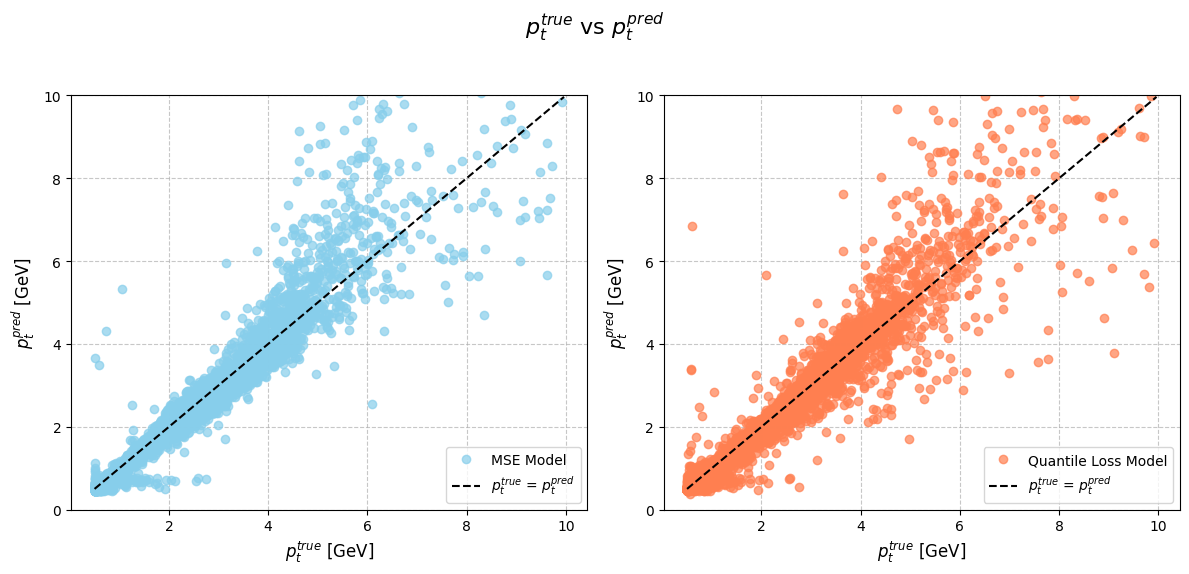

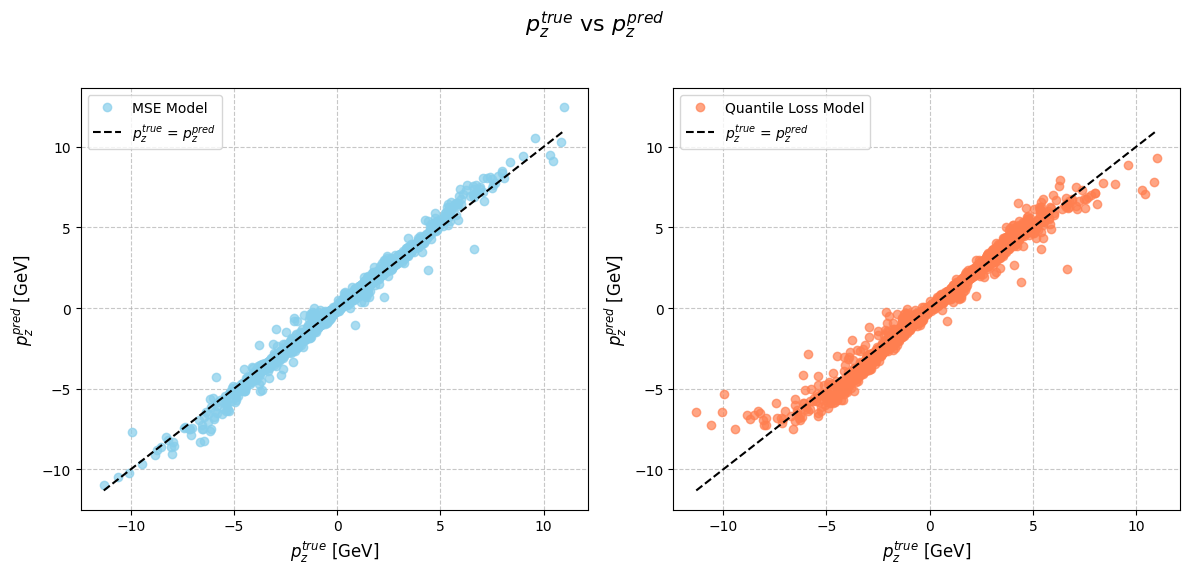

In [35]:
def plot_pi_true_vs_pred():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        
        title = f"${var}^{{true}}$ vs ${var}^{{pred}}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + " [GeV]"
        ylabel = pred_label + " [GeV]"
        filename = f"{var}_true_vs_{var}_pred_square.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        min_pi_true = min(pi_true_list)
        max_pi_true = max(pi_true_list)

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.plot(pi_true_list, pi_pred_mse_list, alpha=0.7, label='MSE Model', color='skyblue', marker='o', linestyle='None')
        # Add x = y line
        plt.plot([min_pi_true, max_pi_true], [min_pi_true, max_pi_true], color='black', linestyle='--', label=f'{true_label} = {pred_label}')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        if var == "p_t":
            plt.ylim(0, 10)

        # Qloss
        plt.subplot(1, 2, 2)
        plt.plot(pi_true_list, pi_pred_qloss_list, alpha=0.7, label='Quantile Loss Model', color='coral', marker='o', linestyle='None')
        # Add x = y line
        plt.plot([min_pi_true, max_pi_true], [min_pi_true, max_pi_true], color='black', linestyle='--', label=f'{true_label} = {pred_label}')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        if var == "p_t":
            plt.ylim(0, 10)


        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_true_vs_pred()

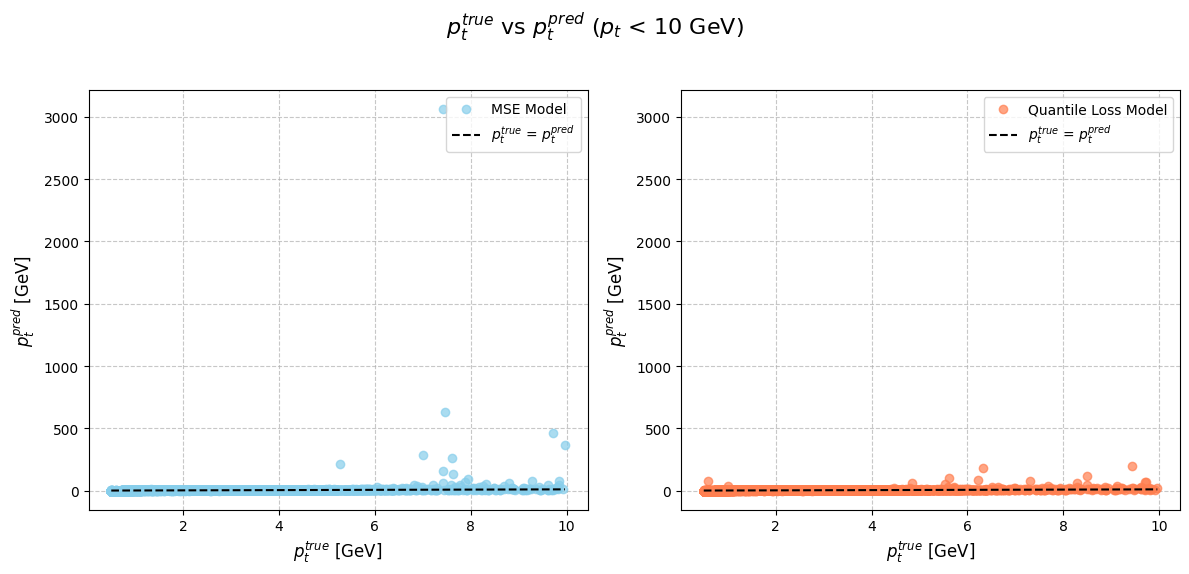

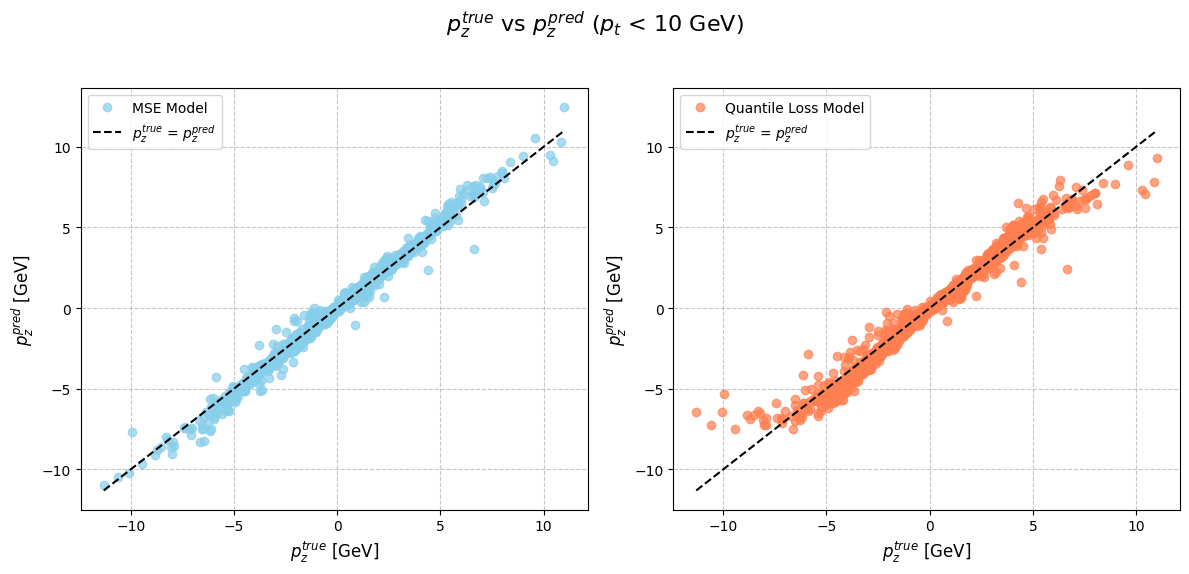

In [14]:
def plot_pi_true_vs_pred_low_pt():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        
        pt_true = np.array(p_true_list)[:, 0]
        mask = pt_true < 10
        pi_true_list = pi_true_list[mask]
        pi_pred_mse_list = pi_pred_mse_list[mask]
        pi_pred_qloss_list = pi_pred_qloss_list[mask]

        title = f"${var}^{{true}}$ vs ${var}^{{pred}}$ ($p_t$ < 10 GeV)"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + " [GeV]"
        ylabel = pred_label + " [GeV]"
        filename = f"{var}_true_vs_{var}_pred_square_low_pt.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        min_pi = min(min(pi_true_list), min(pi_pred_mse_list), min(pi_pred_qloss_list))
        min_pi = min(pi_true_list)
        max_pi = max(max(pi_true_list), max(pi_pred_mse_list), max(pi_pred_qloss_list))
        max_pi = max(pi_true_list)

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.plot(pi_true_list, pi_pred_mse_list, alpha=0.7, label='MSE Model', color='skyblue', marker='o', linestyle='None')
        # Add x = y line
        plt.plot([min_pi, max_pi], [min_pi, max_pi], color='black', linestyle='--', label=f'{true_label} = {pred_label}')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.plot(pi_true_list, pi_pred_qloss_list, alpha=0.7, label='Quantile Loss Model', color='coral', marker='o', linestyle='None')
        # Add x = y line
        plt.plot([min_pi, max_pi], [min_pi, max_pi], color='black', linestyle='--', label=f'{true_label} = {pred_label}')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()


        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_true_vs_pred_low_pt()

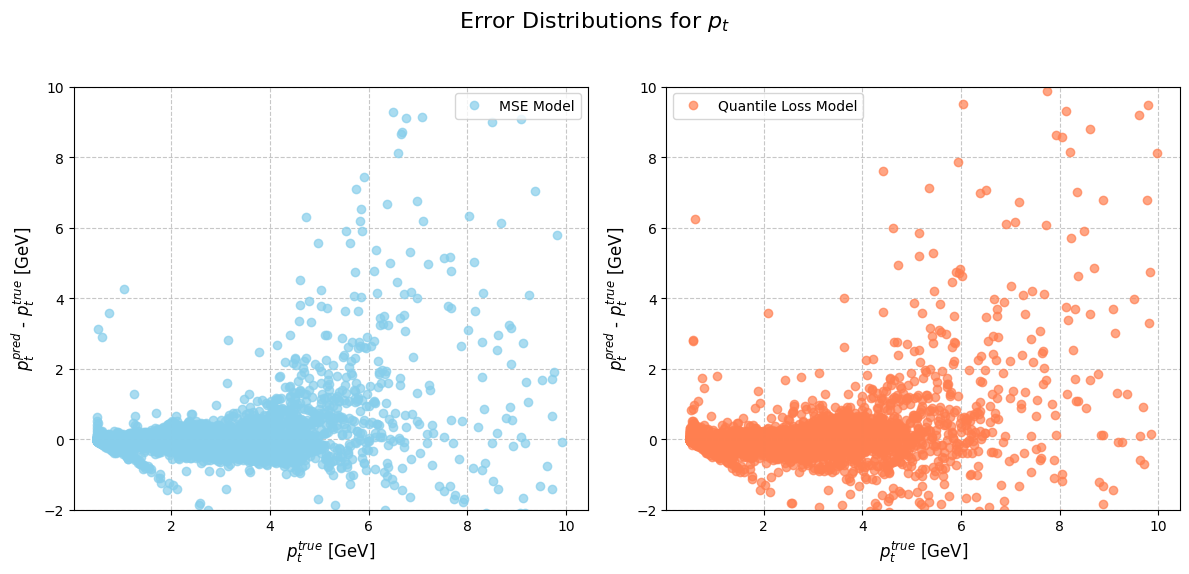

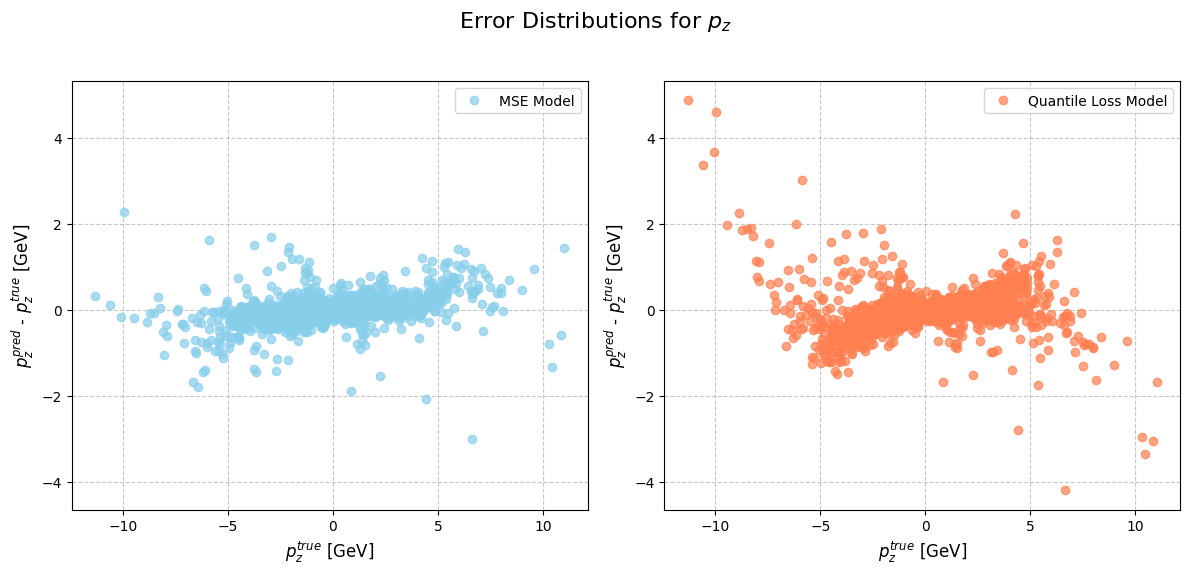

In [36]:
def plot_pi_error_distributions():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        errors_mse_var = pi_pred_mse_list - pi_true_list
        errors_qloss_var = pi_pred_qloss_list - pi_true_list
        
        title = f"Error Distributions for ${var}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + " [GeV]"
        ylabel = f"{pred_label} - {true_label}" + " [GeV]"
        filename = f"error_distributions_{var}.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.plot(pi_true_list, errors_mse_var, alpha=0.7, label='MSE Model', color='skyblue', marker='o', linestyle='None')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        if var == "p_t":
            plt.ylim(-2, 10)

        # Qloss
        plt.subplot(1, 2, 2)
        plt.plot(pi_true_list, errors_qloss_var, alpha=0.7, label='Quantile Loss Model', color='coral', marker='o', linestyle='None')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        if var == "p_t":
            plt.ylim(-2, 10)

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_error_distributions()

[ 0  1  2  4  6  8 10]


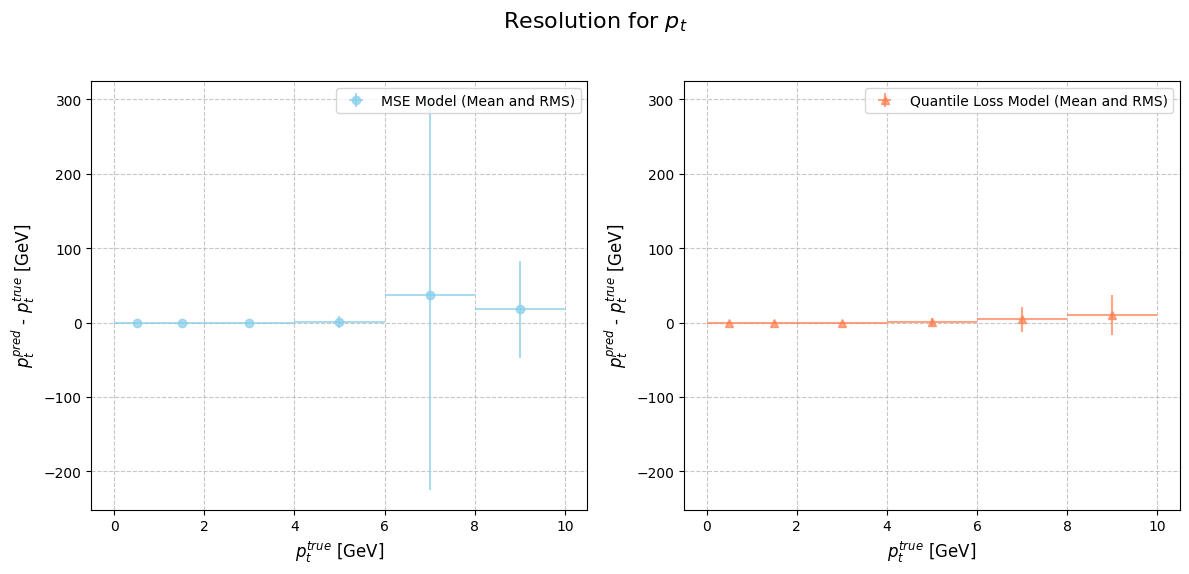

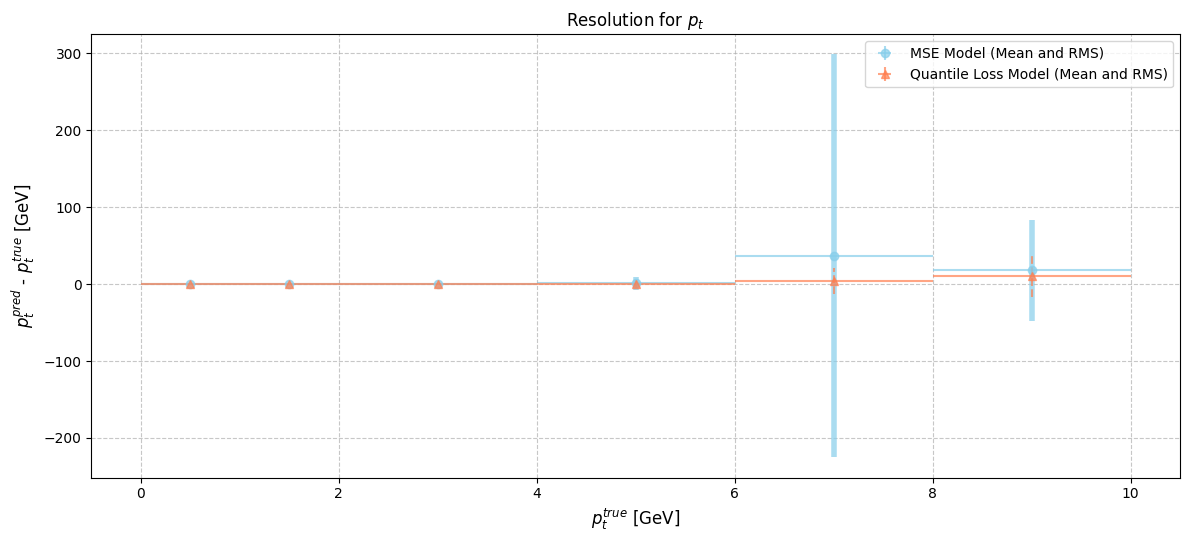

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


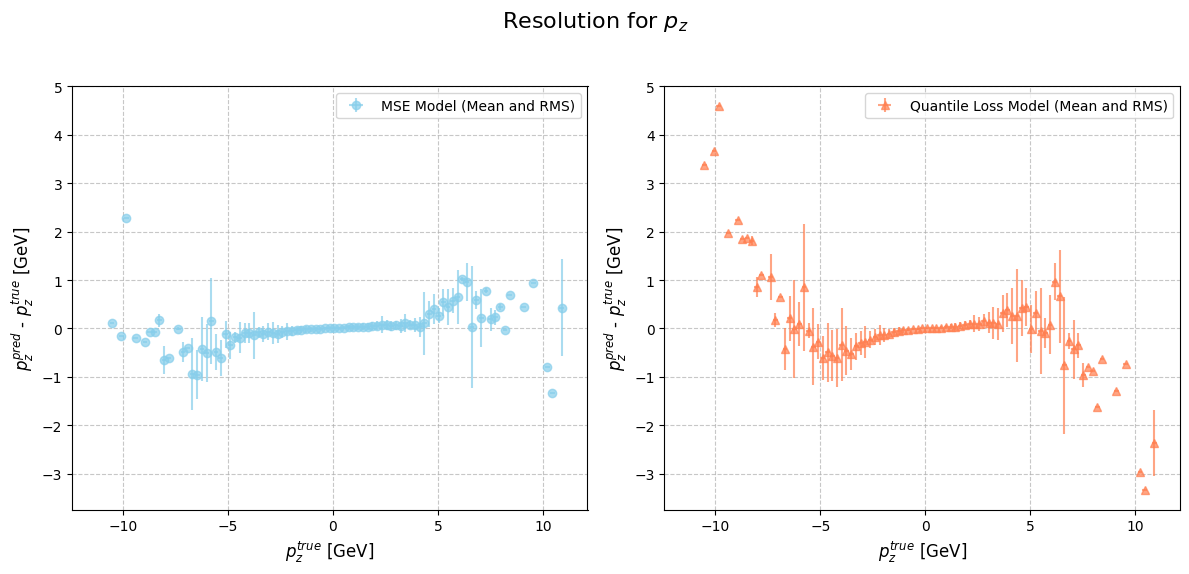

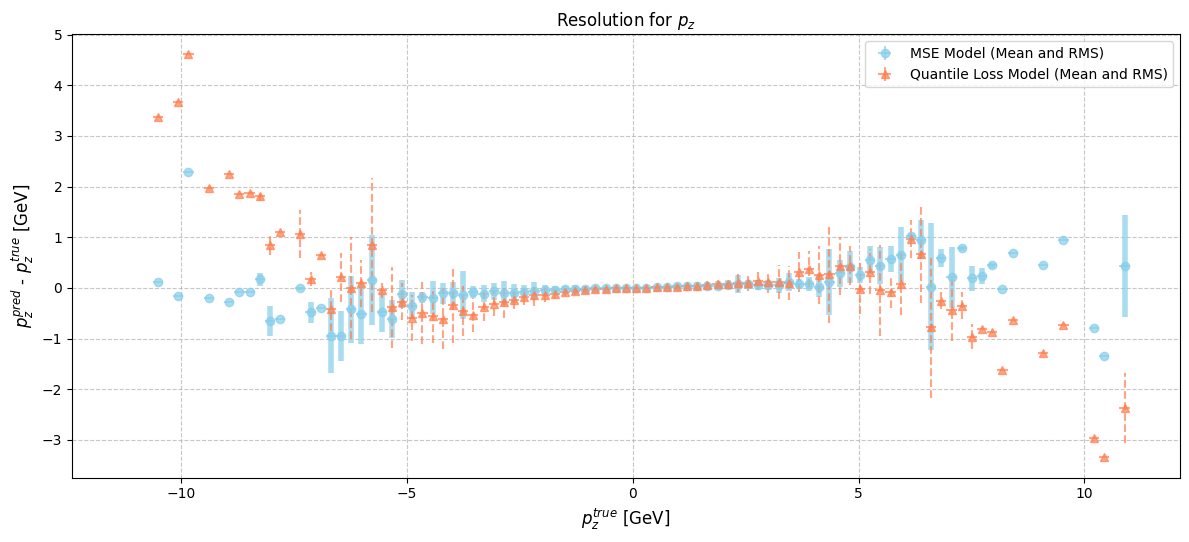

In [16]:
def plot_pi_resolutions():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        errors_mse_var = pi_pred_mse_list - pi_true_list
        errors_qloss_var = pi_pred_qloss_list - pi_true_list

        title = f"Resolution for ${var}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + " [GeV]"
        ylabel = f"{pred_label} - {true_label}" + " [GeV]"
        filename = f"resolution_{var}.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(min(pi_true_list), max(pi_true_list), 100)
        if var_index == 0:
            bins = np.logspace(
                np.log10(min(pi_true_list)), np.log10(max(pi_true_list)), 15
            )
            bins = np.logspace(
                np.log10(min(pi_true_list)), np.log10(50), 10
            )
            bins = np.array([0, 1, 2, 4, 6, 8, 12, 16, 20, 24, 28, 34, 40, 50])
            bins = np.array([0, 1, 2, 4, 6, 8, 10])
            print(bins)

        bin_counts_mse = []
        bin_counts_q_loss = []
        bin_std_mse = []
        bin_std_q_loss = []

        for bin_index in range(len(bins)):
            if bin_index == 0:
                lower_bound = -np.inf
                continue
            else:
                lower_bound = bins[bin_index - 1]
            upper_bound = bins[bin_index]

            sel = (lower_bound < pi_true_list) & (pi_true_list <= upper_bound)
            bin_counts_mse.append(np.mean(errors_mse_var[sel]))
            bin_counts_q_loss.append(np.mean(errors_qloss_var[sel]))
            bin_std_mse.append(np.std(errors_mse_var[sel]))
            bin_std_q_loss.append(np.std(errors_qloss_var[sel]))

        bin_centers = (bins[1:] + bins[:-1]) / 2

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.errorbar(
            bin_centers,
            bin_counts_mse,
            yerr=bin_std_mse,
            xerr=(bins[1:] - bins[:-1]) / 2,
            alpha=0.7,
            label="MSE Model (Mean and RMS)",
            color="skyblue",
            marker="o",
            linestyle="None",
        )
        # # Add x = y line
        # plt.plot([min(pi_true_list), max(pi_true_list)], [min(pi_true_list), max(pi_true_list)], color='black', linestyle='--', label=f'{true_label} = {pred_label}')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.errorbar(
            bin_centers,
            bin_counts_q_loss,
            yerr=bin_std_q_loss,
            xerr=(bins[1:] - bins[:-1]) / 2,
            alpha=0.7,
            label="Quantile Loss Model (Mean and RMS)",
            color="coral",
            marker="^",
            linestyle="None",
        )
        # # Add x = y line
        # plt.plot([min(pi_true_list), max(pi_true_list)], [min(pi_true_list), max(pi_true_list)], color='black', linestyle='--', label=f'{true_label} = {pred_label}')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()

        # One figure
        filename = f"resolution_{var}_one_plot.png"
        filename = output_dir / filename
        bin_sizes = bins[1:] - bins[:-1]
        plt.figure(figsize=(12, 6))
        errobar_1 = plt.errorbar(
            bin_centers,
            bin_counts_mse,
            yerr=bin_std_mse,
            xerr=(bins[1:] - bins[:-1]) / 2,
            alpha=0.7,
            label="MSE Model (Mean and RMS)",
            color="skyblue",
            marker="o",
            linestyle="None",
        )
        errobar_1[-1][1].set_linewidth(4) #errobar_2[-1][0] is the LineCollection objects of the errorbar lines
        shift = bin_sizes * 0.0
        xerr_low = bin_sizes / 2 + shift
        xerr_high = bin_sizes / 2 - shift
        xerr_high[xerr_high < 0] = 0
        errobar_2 = plt.errorbar(
            bin_centers + shift,
            bin_counts_q_loss,
            yerr=bin_std_q_loss,
            xerr=[xerr_low, xerr_high],
            alpha=0.7,
            label="Quantile Loss Model (Mean and RMS)",
            color="coral",
            marker="^",
            linestyle="None",
            
        )
        # Use dashed lines for y error bars
        # https://stackoverflow.com/questions/22995797/can-matplotlib-errorbars-have-a-linestyle-set
        errobar_2[-1][1].set_linestyle('--') #errobar_2[-1][0] is the LineCollection objects of the errorbar lines
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title(title)
        # Specify in the legend that vertical error bars are rms of the distribution
        plt.legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_resolutions()

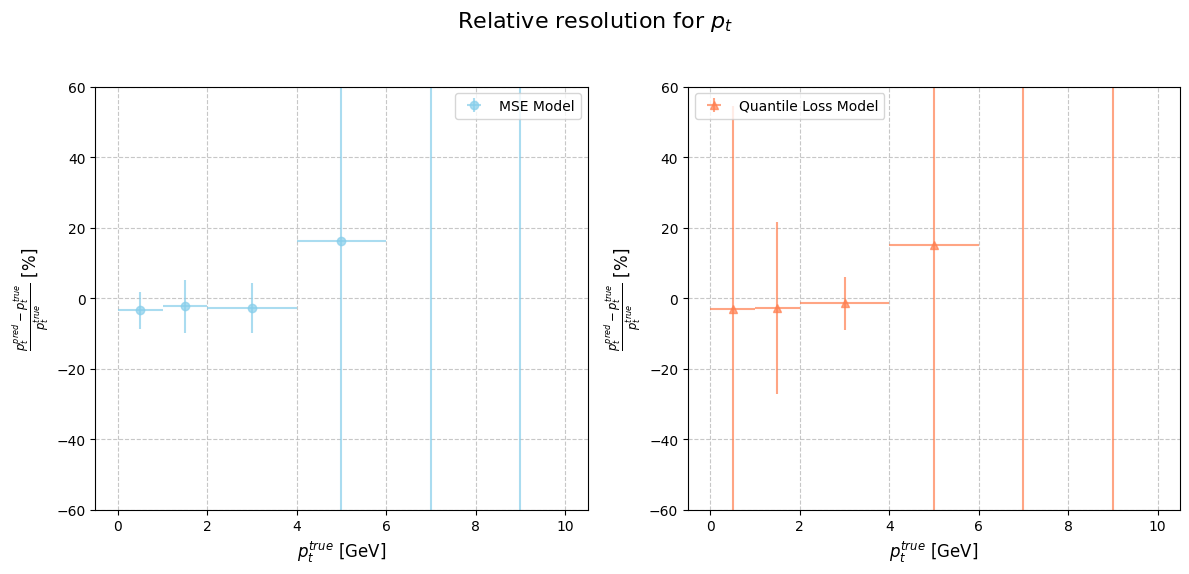

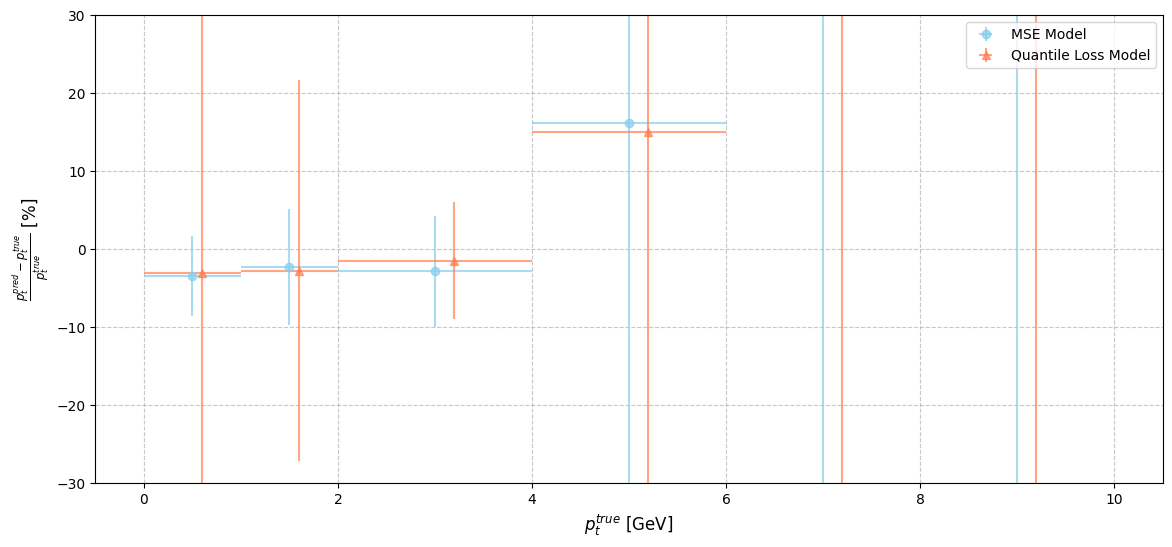

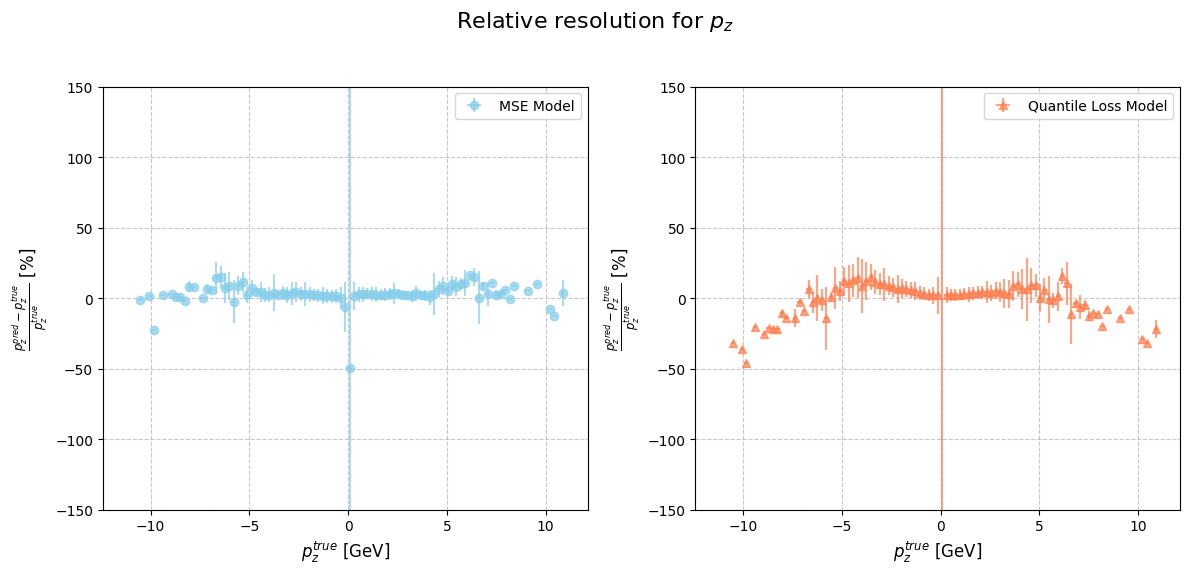

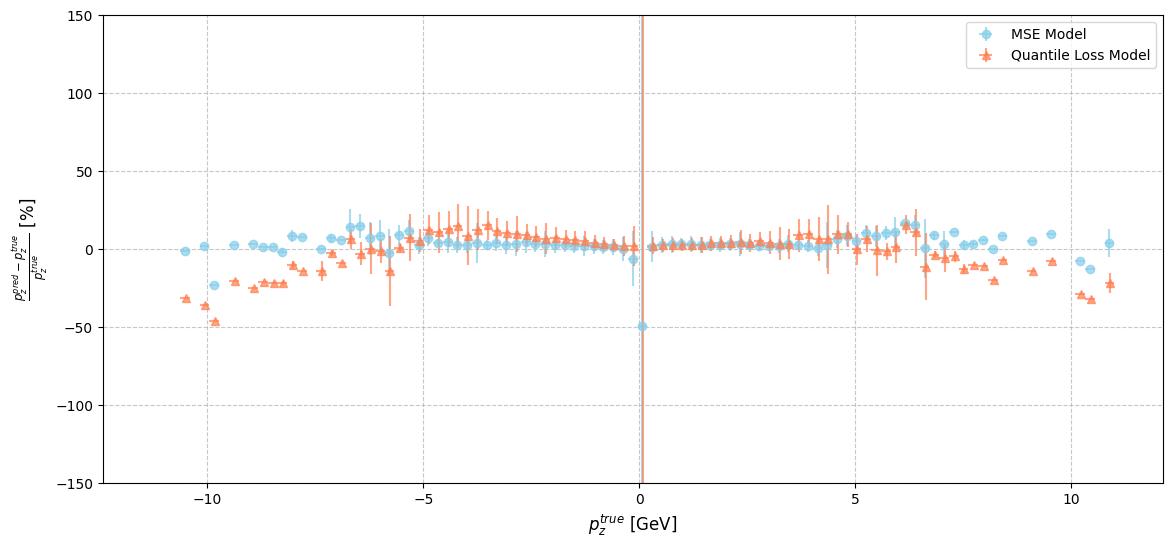

In [38]:
def plot_pi_rel_resolutions():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        errors_mse_var = pi_pred_mse_list - pi_true_list
        errors_qloss_var = pi_pred_qloss_list - pi_true_list

        relative_errors_mse_var = errors_mse_var / pi_true_list
        relative_errors_qloss_var = errors_qloss_var / pi_true_list

        # Make it percentage
        relative_errors_mse_var *= 100
        relative_errors_qloss_var *= 100

        title = f"Relative resolution for ${var}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + " [GeV]"
        ylabel = r"$\frac{" + f"{pred_label} - {true_label}".replace("$", "") + "}{" + f"{true_label}".replace("$", "") + "}$" + " [%]"
        filename = f"rel_resolution_{var}.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(min(pi_true_list), max(pi_true_list), 100)
        if var_index == 0:
            bins = np.logspace(
                np.log10(min(pi_true_list)), np.log10(max(pi_true_list)), 15
            )
            bins = np.logspace(
                np.log10(min(pi_true_list)), np.log10(50), 10
            )
            bins = np.array([0, 1, 2, 4, 6, 8, 12, 16, 20, 24, 28, 34, 40, 50])
            bins = np.array([0, 1, 2, 4, 6, 8, 10])
            # print(bins)

        bin_counts_mse = []
        bin_counts_q_loss = []
        bin_std_mse = []
        bin_std_q_loss = []

        for bin_index in range(len(bins)):
            if bin_index == 0:
                lower_bound = -np.inf
                continue
            else:
                lower_bound = bins[bin_index - 1]
            upper_bound = bins[bin_index]

            sel = (lower_bound < pi_true_list) & (pi_true_list <= upper_bound)
            bin_counts_mse.append(np.mean(relative_errors_mse_var[sel]))
            bin_counts_q_loss.append(np.mean(relative_errors_qloss_var[sel]))
            bin_std_mse.append(np.std(relative_errors_mse_var[sel]))
            bin_std_q_loss.append(np.std(relative_errors_qloss_var[sel]))

        bin_centers = (bins[1:] + bins[:-1]) / 2

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.errorbar(
            bin_centers,
            bin_counts_mse,
            yerr=bin_std_mse,
            xerr=(bins[1:] - bins[:-1]) / 2,
            alpha=0.7,
            label="MSE Model",
            color="skyblue",
            marker="o",
            linestyle="None",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        if var == "p_t":
            plt.ylim(-30, 30)
        if var_index == 1:
            plt.ylim(-1.5*100, 1.5*100)

        # Qloss
        plt.subplot(1, 2, 2)
        plt.errorbar(
            bin_centers,
            bin_counts_q_loss,
            yerr=bin_std_q_loss,
            xerr=(bins[1:] - bins[:-1]) / 2,
            alpha=0.7,
            label="Quantile Loss Model",
            color="coral",
            marker="^",
            linestyle="None",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        if var == "p_t":
            plt.ylim(-30, 30)
        if var_index == 1:
            plt.ylim(-1.5*100, 1.5*100)

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()

        # One figure
        filename = f"rel_resolution_{var}_one_plot.png"
        filename = output_dir / filename
        bin_sizes = bin_sizes = bins[1:] - bins[:-1]
        plt.figure(figsize=(12, 6))
        plt.errorbar(
            bin_centers,
            bin_counts_mse,
            yerr=bin_std_mse,
            xerr=(bins[1:] - bins[:-1]) / 2,
            alpha=0.7,
            label="MSE Model",
            color="skyblue",
            marker="o",
            linestyle="None",
        )
        shift = bin_sizes * 0.1
        xerr_low = bin_sizes / 2 + shift
        xerr_high = bin_sizes / 2 - shift
        xerr_high[xerr_high < 0] = 0
        plt.errorbar(
            bin_centers + shift,
            bin_counts_q_loss,
            yerr=bin_std_q_loss,
            xerr=[xerr_low, xerr_high],
            alpha=0.7,
            label="Quantile Loss Model",
            color="coral",
            marker="^",
            linestyle="None",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        if var == "p_t":
            plt.ylim(-30, 30)
        if var_index == 1:
            plt.ylim(-1.5*100, 1.5*100)
        # if var_index == 0:
        #     plt.xscale("log")
        #     # plt.yscale("log")
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_rel_resolutions()

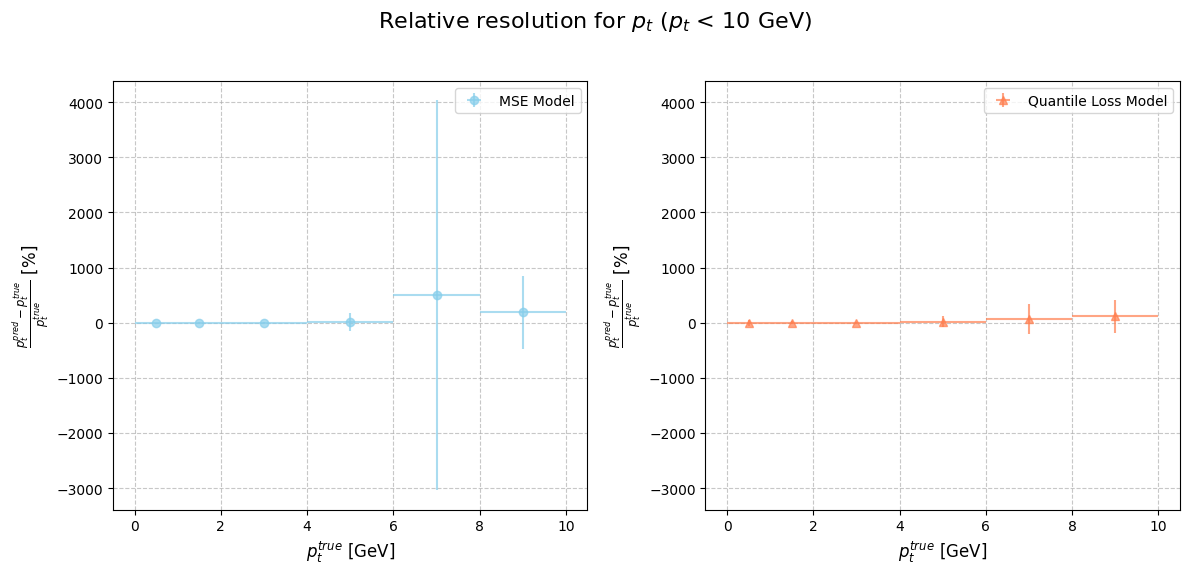

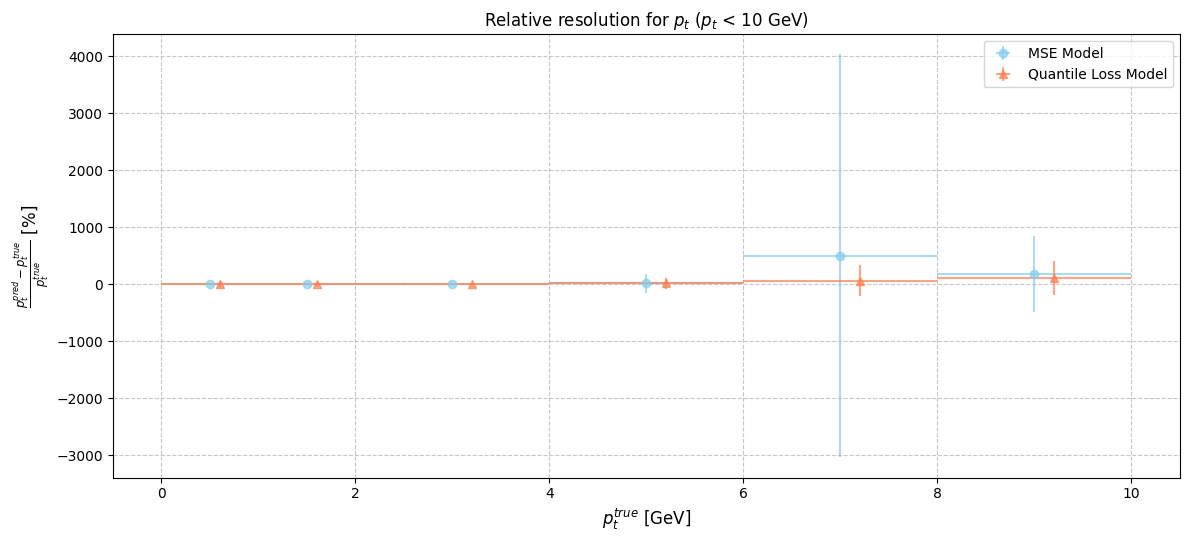

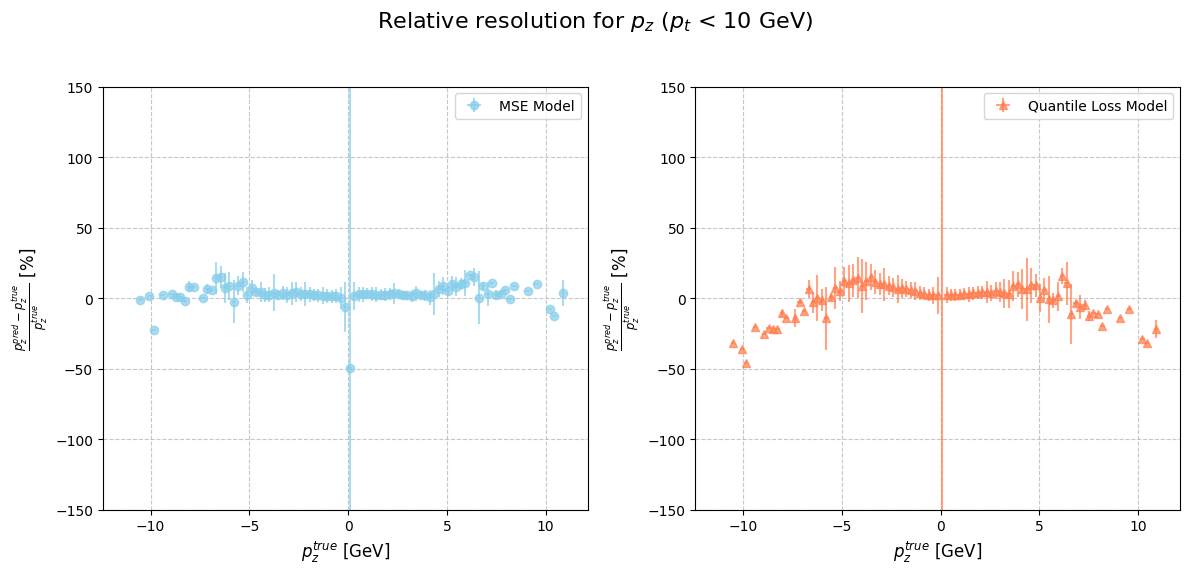

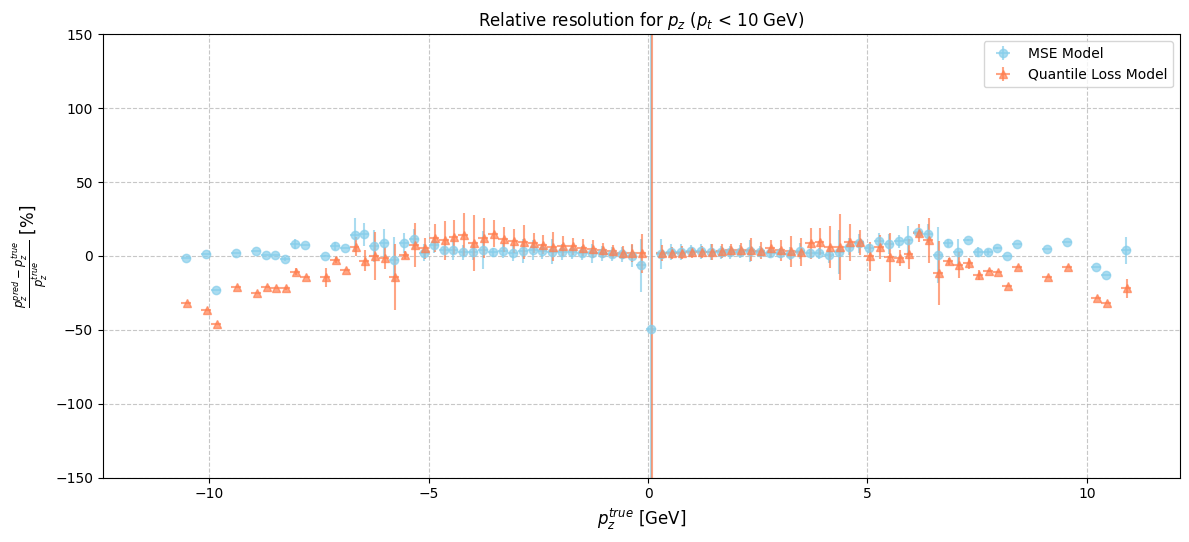

In [18]:
def plot_pi_rel_resolutions_low_pt():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        errors_mse_var = pi_pred_mse_list - pi_true_list
        errors_qloss_var = pi_pred_qloss_list - pi_true_list

        relative_errors_mse_var = errors_mse_var / pi_true_list
        relative_errors_qloss_var = errors_qloss_var / pi_true_list

        # Make it percentage
        relative_errors_mse_var *= 100
        relative_errors_qloss_var *= 100

        title = f"Relative resolution for ${var}$ ($p_t$ < 10 GeV)"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + " [GeV]"
        ylabel = r"$\frac{" + f"{pred_label} - {true_label}".replace("$", "") + "}{" + f"{true_label}".replace("$", "") + "}$" + " [%]"
        filename = f"rel_resolution_{var}_low_pt.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(min(pi_true_list), max(pi_true_list), 100)
        if var_index == 0:
            bins = np.logspace(
                np.log10(min(pi_true_list)), np.log10(max(pi_true_list)), 15
            )
            bins = np.logspace(
                np.log10(min(pi_true_list)), np.log10(50), 10
            )
            bins = np.array([0, 1, 2, 4, 6, 8, 10])
            # print(bins)

        bin_counts_mse = []
        bin_counts_q_loss = []
        bin_std_mse = []
        bin_std_q_loss = []

        for bin_index in range(len(bins)):
            if bin_index == 0:
                lower_bound = -np.inf
                continue
            else:
                lower_bound = bins[bin_index - 1]
            upper_bound = bins[bin_index]

            sel = (lower_bound < pi_true_list) & (pi_true_list <= upper_bound)
            bin_counts_mse.append(np.mean(relative_errors_mse_var[sel]))
            bin_counts_q_loss.append(np.mean(relative_errors_qloss_var[sel]))
            bin_std_mse.append(np.std(relative_errors_mse_var[sel]))
            bin_std_q_loss.append(np.std(relative_errors_qloss_var[sel]))

        bin_centers = (bins[1:] + bins[:-1]) / 2

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.errorbar(
            bin_centers,
            bin_counts_mse,
            yerr=bin_std_mse,
            xerr=(bins[1:] - bins[:-1]) / 2,
            alpha=0.7,
            label="MSE Model",
            color="skyblue",
            marker="o",
            linestyle="None",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        if var_index == 1:
            plt.ylim(-1.5*100, 1.5*100)

        # Qloss
        plt.subplot(1, 2, 2)
        plt.errorbar(
            bin_centers,
            bin_counts_q_loss,
            yerr=bin_std_q_loss,
            xerr=(bins[1:] - bins[:-1]) / 2,
            alpha=0.7,
            label="Quantile Loss Model",
            color="coral",
            marker="^",
            linestyle="None",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        if var_index == 1:
            plt.ylim(-1.5*100, 1.5*100)

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()

        # One figure
        filename = f"rel_resolution_{var}_low_pt_one_plot.png"
        filename = output_dir / filename
        bin_sizes = bin_sizes = bins[1:] - bins[:-1]
        plt.figure(figsize=(12, 6))
        plt.errorbar(
            bin_centers,
            bin_counts_mse,
            yerr=bin_std_mse,
            xerr=(bins[1:] - bins[:-1]) / 2,
            alpha=0.7,
            label="MSE Model",
            color="skyblue",
            marker="o",
            linestyle="None",
        )
        shift = bin_sizes * 0.1
        xerr_low = bin_sizes / 2 + shift
        xerr_high = bin_sizes / 2 - shift
        xerr_high[xerr_high < 0] = 0
        plt.errorbar(
            bin_centers + shift,
            bin_counts_q_loss,
            yerr=bin_std_q_loss,
            xerr=[xerr_low, xerr_high],
            alpha=0.7,
            label="Quantile Loss Model",
            color="coral",
            marker="^",
            linestyle="None",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        plt.title(title)
        if var_index == 1:
            plt.ylim(-1.5*100, 1.5*100)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        # if i == 0:
        #     plt.xscale("log")
        #     # plt.yscale("log")
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_rel_resolutions_low_pt()

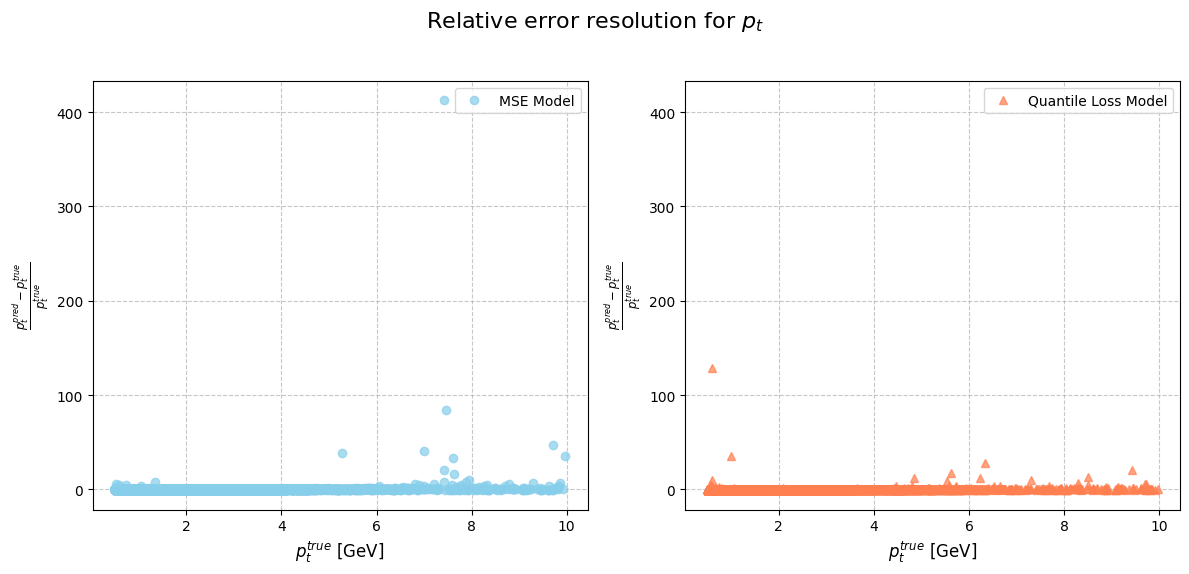

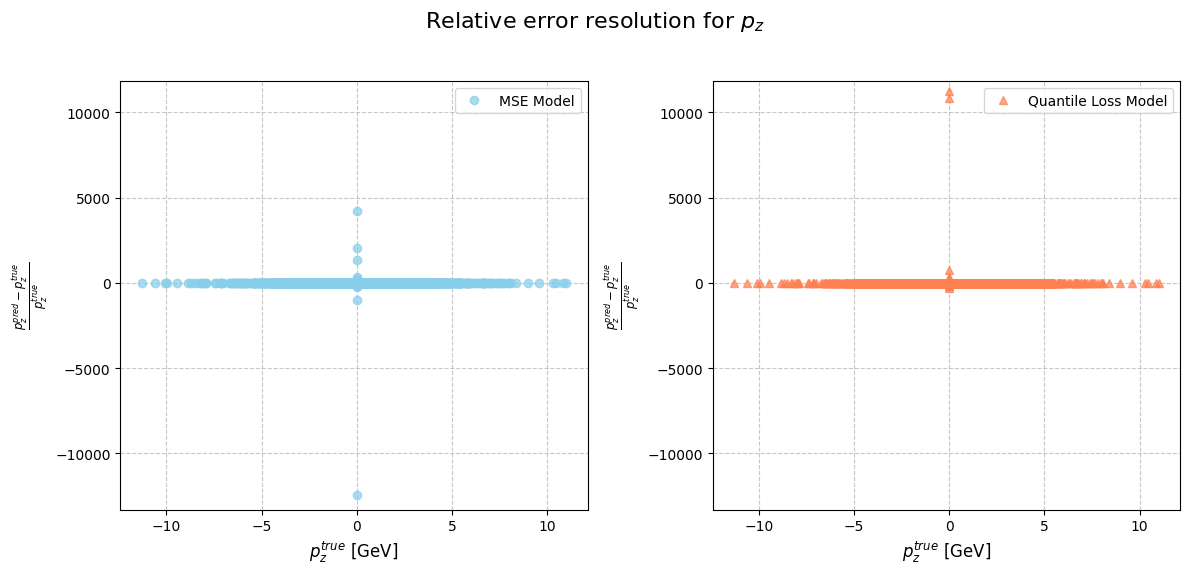

In [19]:
def plot_pi_rel_error_resolutions():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        errors_mse_var = pi_pred_mse_list - pi_true_list
        errors_qloss_var = pi_pred_qloss_list - pi_true_list

        relative_errors_mse_var = errors_mse_var / pi_true_list
        relative_errors_qloss_var = errors_qloss_var / pi_true_list
        
        title = f"Relative error resolution for ${var}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + " [GeV]"
        ylabel = r"$\frac{" + f"{pred_label} - {true_label}".replace("$", "") + "}{" + f"{true_label}".replace("$", "") + "}$"
        filename = f"rel_error_resolution_{var}.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.plot(
            pi_true_list,
            relative_errors_mse_var,
            alpha=0.7,
            label="MSE Model",
            color="skyblue",
            marker="o",
            linestyle="None",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.plot(
            pi_true_list,
            relative_errors_qloss_var,
            alpha=0.7,
            label="Quantile Loss Model",
            color="coral",
            marker="^",
            linestyle="None",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()

plot_pi_rel_error_resolutions()

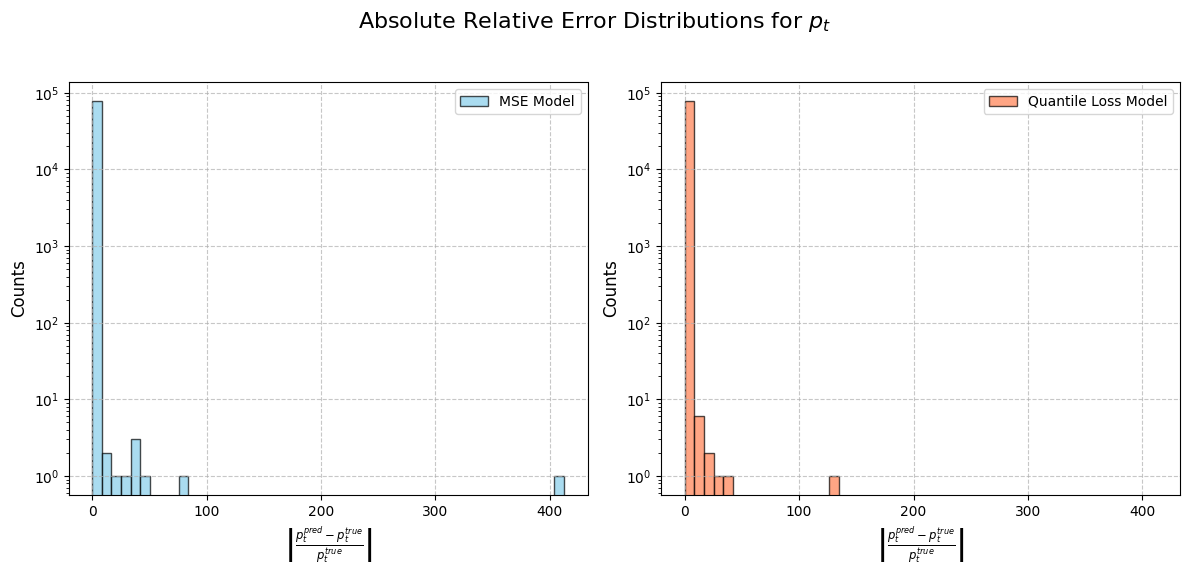

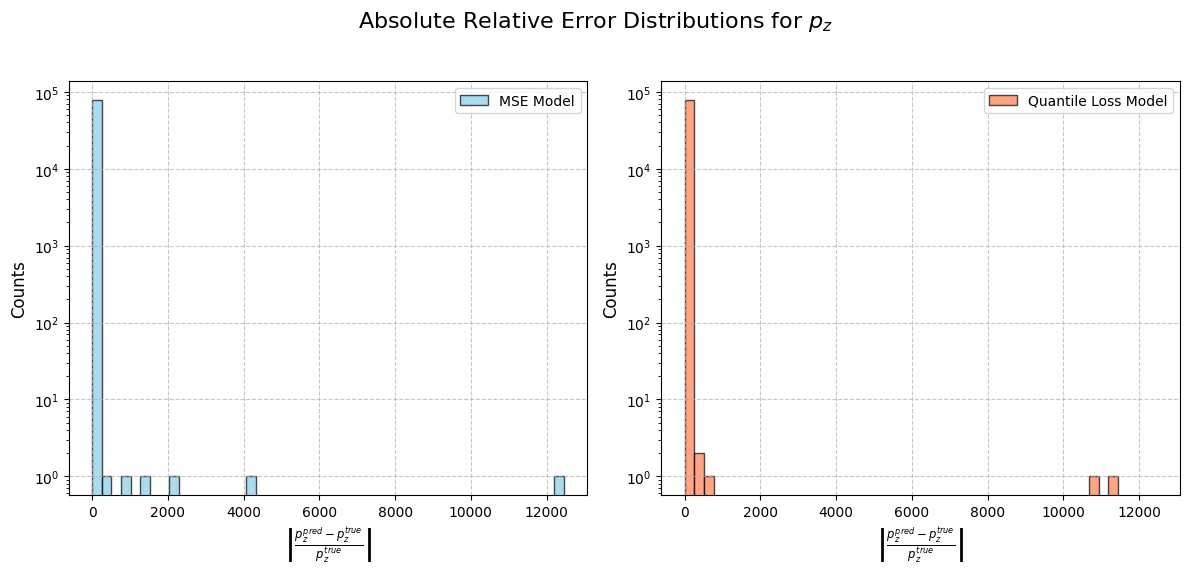

In [20]:
def plot_pi_absolute_relative_error_distributions():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        errors_mse_var = pi_pred_mse_list - pi_true_list
        errors_qloss_var = pi_pred_qloss_list - pi_true_list

        relative_errors_mse_var = errors_mse_var / pi_true_list
        relative_errors_qloss_var = errors_qloss_var / pi_true_list

        abs_relative_errors_mse_var = np.abs(relative_errors_mse_var)
        abs_relative_errors_qloss_var = np.abs(relative_errors_qloss_var)
        
        title = f"Absolute Relative Error Distributions for ${var}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\left|\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}\\right|$"
        ylabel = "Counts"
        filename = f"absolute_relative_error_distributions_{var}.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            0,
            max(
                max(abs_relative_errors_mse_var),
                max(abs_relative_errors_qloss_var),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            abs_relative_errors_mse_var,
            bins=bins,
            alpha=0.7,
            label="MSE Model",
            color="skyblue",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            abs_relative_errors_qloss_var,
            bins=bins,
            alpha=0.7,
            label="Quantile Loss Model",
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_absolute_relative_error_distributions()

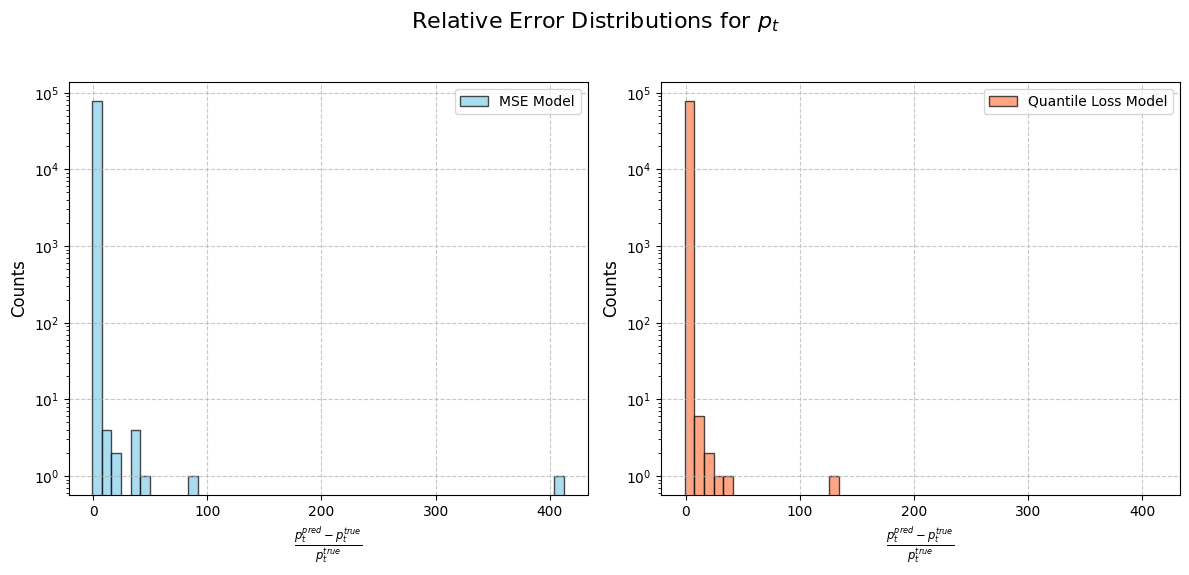

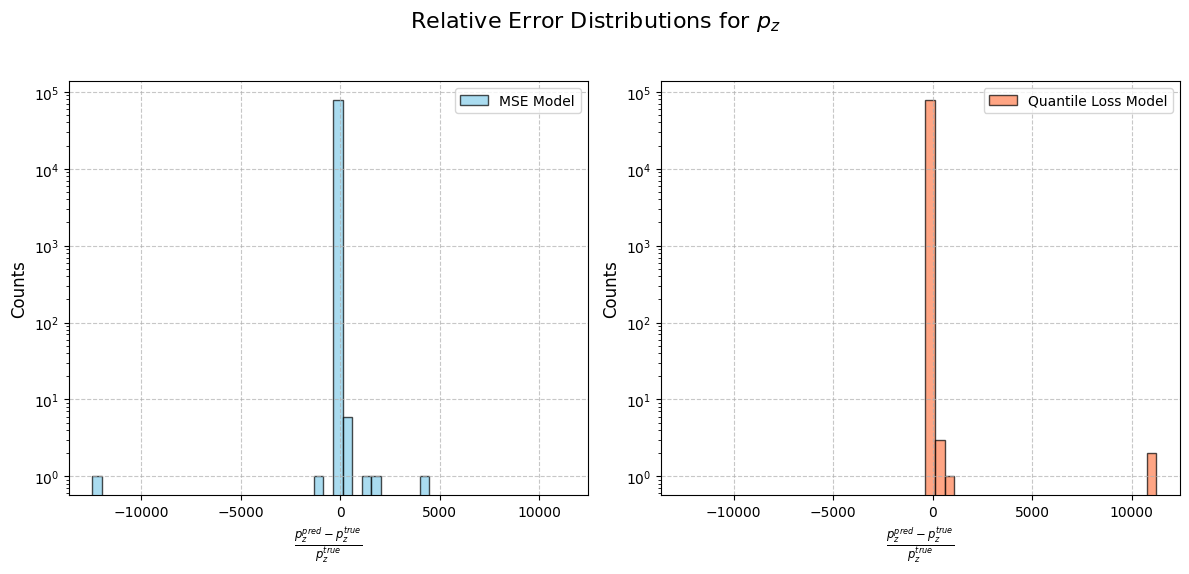

In [21]:
def plot_pi_relative_error_distributions():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        errors_mse_var = pi_pred_mse_list - pi_true_list
        errors_qloss_var = pi_pred_qloss_list - pi_true_list

        relative_errors_mse_var = errors_mse_var / pi_true_list
        relative_errors_qloss_var = errors_qloss_var / pi_true_list
        
        title = f"Relative Error Distributions for ${var}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Counts"
        filename = f"relative_error_distributions_{var}.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(relative_errors_mse_var), min(relative_errors_qloss_var)),
            max(
                max(relative_errors_mse_var),
                max(relative_errors_qloss_var),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            relative_errors_mse_var,
            bins=bins,
            alpha=0.7,
            label="MSE Model",
            color="skyblue",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            relative_errors_qloss_var,
            bins=bins,
            alpha=0.7,
            label="Quantile Loss Model",
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_relative_error_distributions()

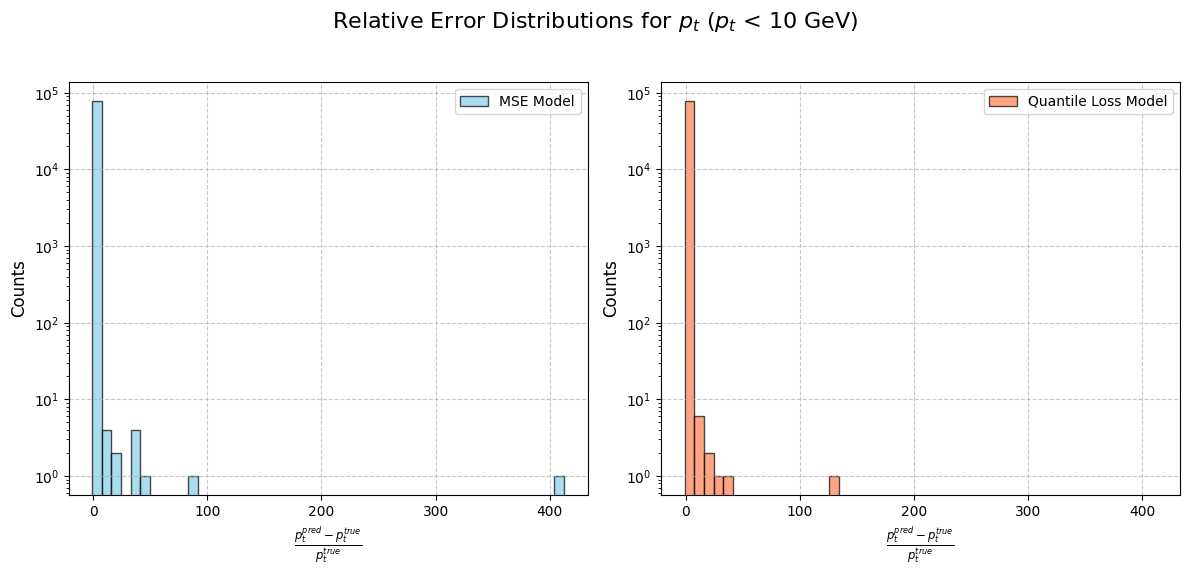

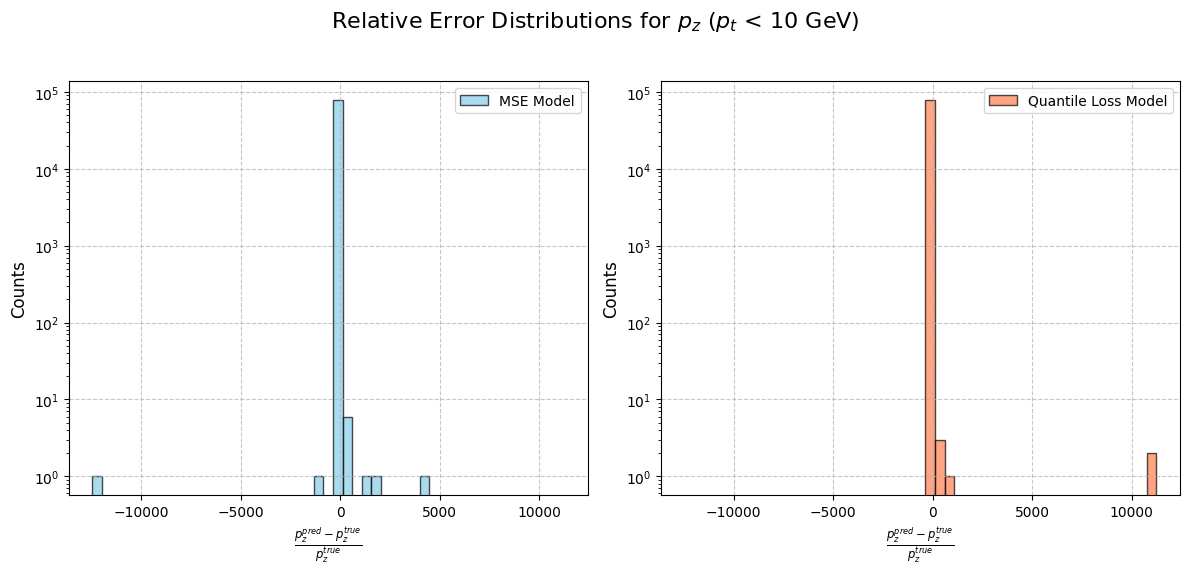

In [22]:
def plot_pi_relative_error_distributions_low_pt():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        errors_mse_var = pi_pred_mse_list - pi_true_list
        errors_qloss_var = pi_pred_qloss_list - pi_true_list

        relative_errors_mse_var = errors_mse_var / pi_true_list
        relative_errors_qloss_var = errors_qloss_var / pi_true_list

        pt_true = np.array(p_true_list)[:, 0]
        mask = pt_true < 10
        relative_errors_mse_var = relative_errors_mse_var[mask]
        relative_errors_qloss_var = relative_errors_qloss_var[mask]
        
        title = f"Relative Error Distributions for ${var}$ ($p_t$ < 10 GeV)"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Counts"
        filename = f"relative_error_distributions_{var}_low_pt.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(relative_errors_mse_var), min(relative_errors_qloss_var)),
            max(
                max(relative_errors_mse_var),
                max(relative_errors_qloss_var),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            relative_errors_mse_var,
            bins=bins,
            alpha=0.7,
            label="MSE Model",
            color="skyblue",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            relative_errors_qloss_var,
            bins=bins,
            alpha=0.7,
            label="Quantile Loss Model",
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_relative_error_distributions_low_pt()

In [ ]:
bad_tracks_q[i][0]

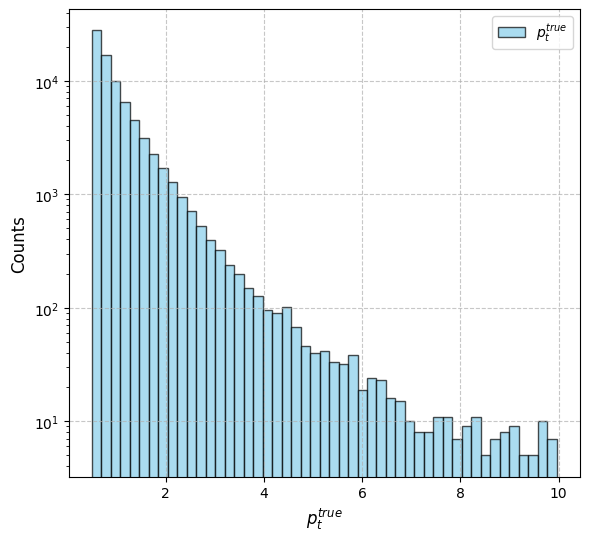

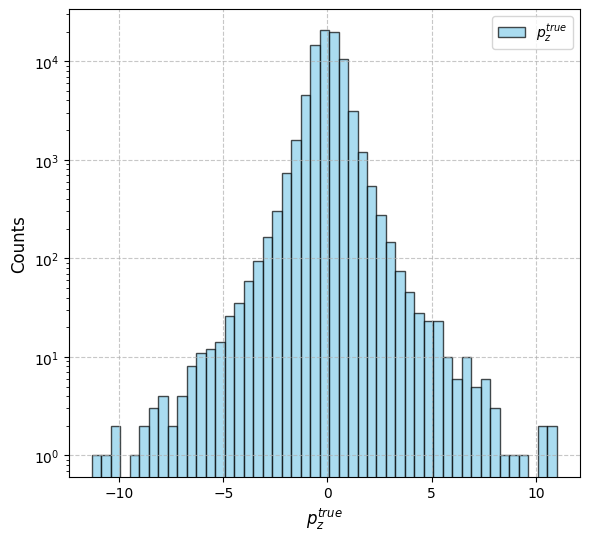

In [23]:
def plot_alone_pi():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        title = f"${var}^{{true}}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label
        filename = f"{var}_true.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6, 6))

        bins = np.linspace(
            min(pi_true_list),
                max(pi_true_list),
            50,
        )

        plt.hist(
            pi_true_list,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        # plt.title(title)
        plt.legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_alone_pi()

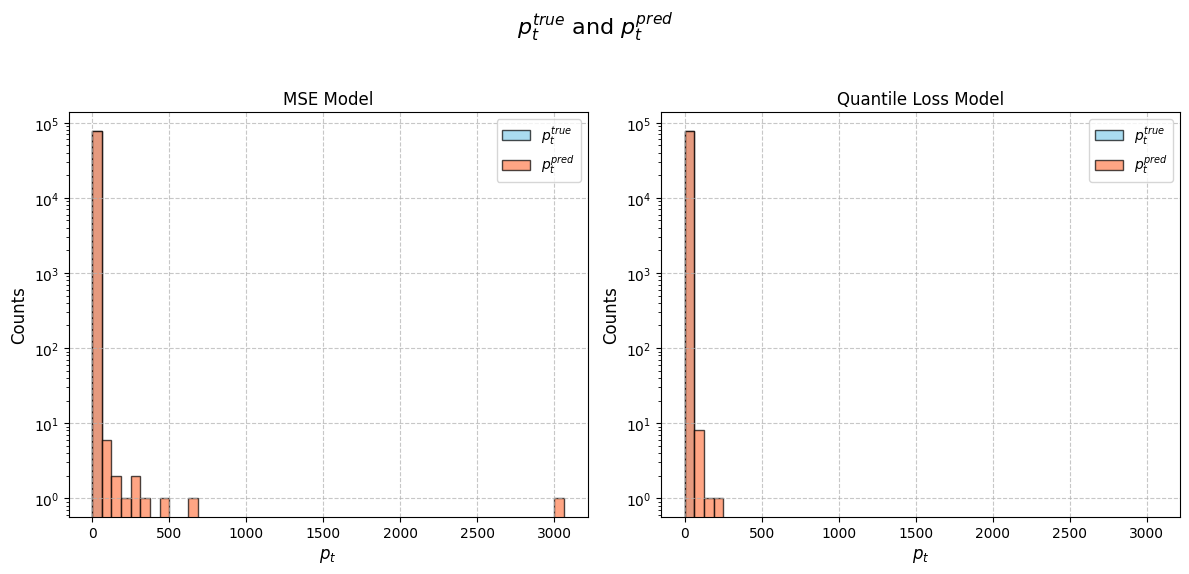

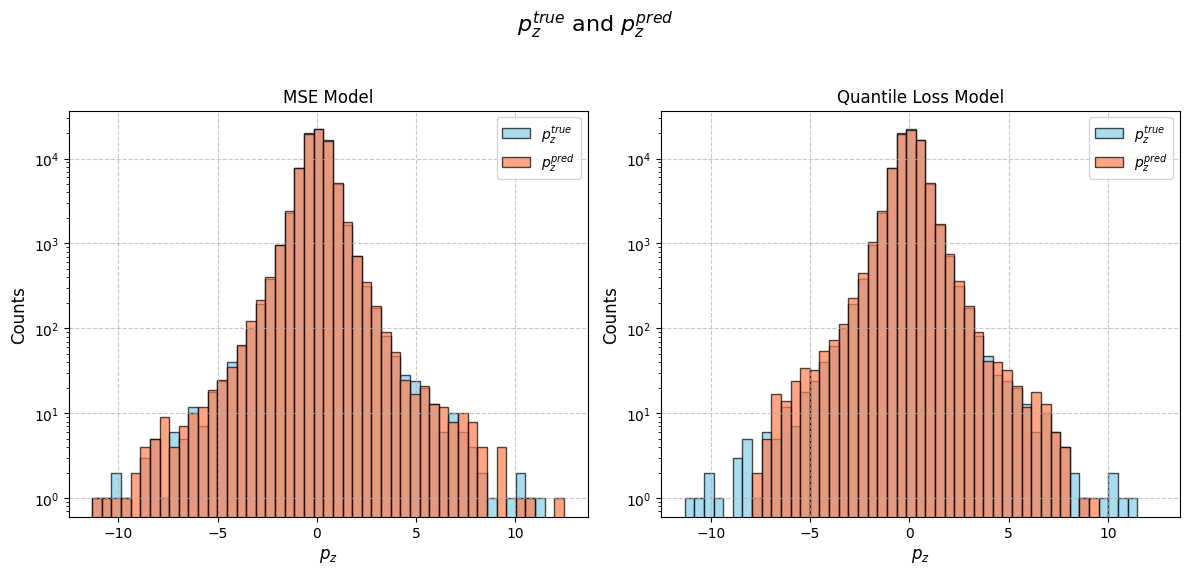

In [24]:
def plot_pi():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        
        title = f"${var}^{{true}}$ and ${var}^{{pred}}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"${var}$"
        filename = f"{var}_true_and_{var}_pred.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(pi_true_list), min(pi_pred_mse_list), min(pi_pred_qloss_list)),
            max(
                max(pi_true_list),
                max(pi_pred_mse_list),
                max(pi_pred_qloss_list),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            pi_true_list,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_mse_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            pi_true_list,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_qloss_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi()

In [25]:
def plot_pi_cdf():
    """Plot CDF of p_t and p_z"""
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        
        title = f"CDF of ${var}^{{true}}$ and ${var}^{{pred}}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"CDF of ${var}$"
        filename = f"{var}_true_and_{var}_pred_cdf.png"
        filename = output_dir / filename

        # Import necessary CDF function
        from scipy.stats import norm

        pi_true_list_cdf = np.sort(pi_true_list)
        pi_pred_mse_list_cdf = np.sort(pi_pred_mse_list)
        pi_pred_qloss_list_cdf = np.sort(pi_pred_qloss_list)

        pi_true_list_cdf_ = np.linspace(0, 1, len(pi_true_list_cdf))
        pi_pred_mse_list_cdf_ = np.linspace(0, 1, len(pi_pred_mse_list_cdf))
        pi_pred_qloss_list_cdf_ = np.linspace(0, 1, len(pi_pred_qloss_list_cdf))

        pi_true_list_cdf = norm.ppf(pi_true_list_cdf_)
        pi_pred_mse_list_cdf = norm.ppf(pi_pred_mse_list_cdf_)
        pi_pred_qloss_list_cdf = norm.ppf(pi_pred_qloss_list_cdf_)

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(pi_true_list), min(pi_pred_mse_list), min(pi_pred_qloss_list)),
            max(
                max(pi_true_list),
                max(pi_pred_mse_list),
                max(pi_pred_qloss_list),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            pi_true_list,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_mse_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            pi_true_list,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_qloss_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


# plot_pi_cdf()

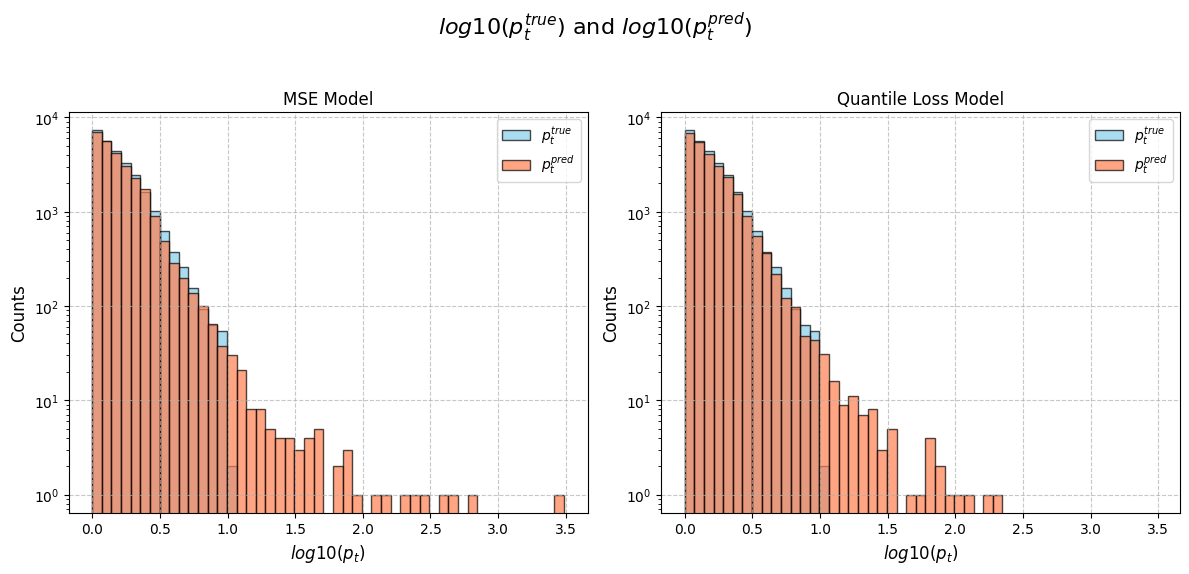

/tmp/ipykernel_68902/3716710468.py:21: RuntimeWarning: invalid value encountered in log10
  max(np.log10(pi_true_list)),
/tmp/ipykernel_68902/3716710468.py:22: RuntimeWarning: invalid value encountered in log10
  max(np.log10(pi_pred_mse_list)),
/tmp/ipykernel_68902/3716710468.py:23: RuntimeWarning: invalid value encountered in log10
  max(np.log10(pi_pred_qloss_list)),
/tmp/ipykernel_68902/3716710468.py:31: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_true_list),
/tmp/ipykernel_68902/3716710468.py:39: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_pred_mse_list),
/tmp/ipykernel_68902/3716710468.py:56: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_true_list),
/tmp/ipykernel_68902/3716710468.py:64: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_pred_qloss_list),


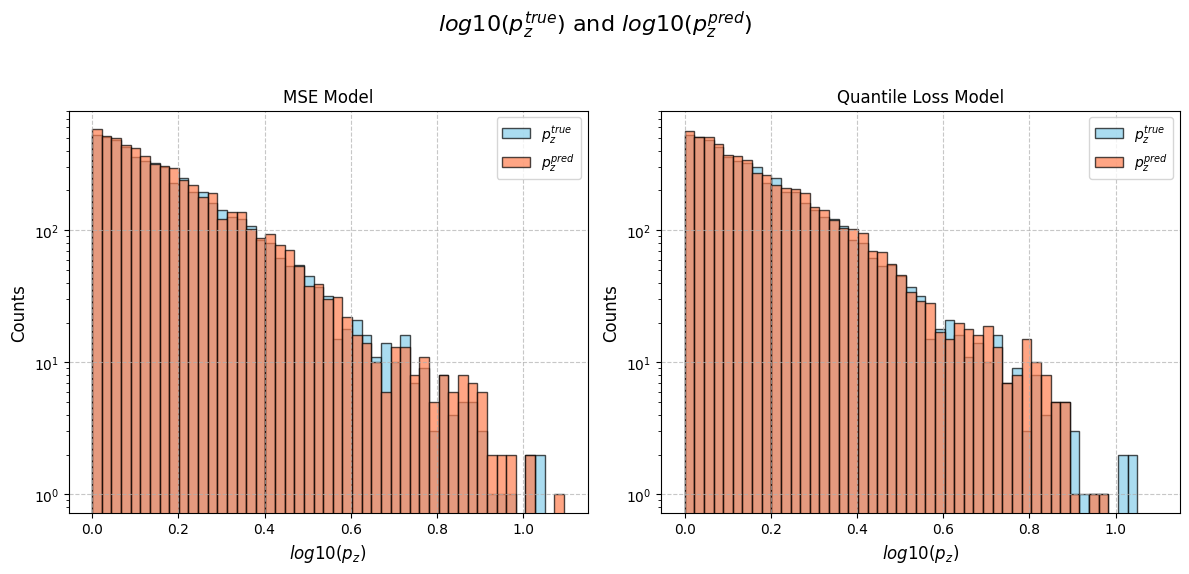

In [26]:
def plot_log10_pi():
    for var_index, var in enumerate(target_labels):
        pi_true_list = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        
        title = f"$log10({var}^{{true}})$ and $log10({var}^{{pred}})$"
        xlabel = f"$log10({var})$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        filename = f"log10_{var}_true_and_log10_{var}_pred.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            0,
            max(
                max(np.log10(pi_true_list)),
                max(np.log10(pi_pred_mse_list)),
                max(np.log10(pi_pred_qloss_list)),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            np.log10(pi_true_list),
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            np.log10(pi_pred_mse_list),
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            np.log10(pi_true_list),
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            np.log10(pi_pred_qloss_list),
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_log10_pi()

In [27]:

import torch.nn.functional as F
from sklearn.utils import resample
from scipy.stats import bootstrap

def evaluate_models():
    # Initialize lists to store the MAE values
    m_transf_mae_pt = []
    m_transf_mae_pz = []
    q_transf_mae_pt = []
    q_transf_mae_pz = []

    pt_conf_mae_list = []
    batch_limit = 10
    epochs = 1
    for epoch in tqdm(range(epochs)):
        with torch.no_grad():
            for i, (input, mask, target) in enumerate(tqdm(tl)):
                if i >= batch_limit:
                    break
                # Transformer MSE
                pred1 = transf_mse_model(input, mask=mask)
                pt_mae1 = F.l1_loss(pred1[:, 0], target[:, 0])
                pz_mae1 = F.l1_loss(pred1[:, 1], target[:, 1])

                m_transf_mae_pt.append(pt_mae1.item())
                m_transf_mae_pz.append(pz_mae1.item())

                # Transformer Qloss
                pred2 = qloss_transf_tt_model(input, mask=mask)
                pt_mae2 = F.l1_loss(pred2[:, 0], target[:, 0])
                pz_mae2 = F.l1_loss(pred2[:, 1], target[:, 1])

                q_transf_mae_pt.append(pt_mae2.item())
                q_transf_mae_pz.append(pz_mae2.item())

                # conformal fitt squares
                # pt_conf_mae = conformal_mae(input, target)
                # pt_conf_mae_list.append(pt_conf_mae.item())

    # Convert lists to numpy arrays
    m_transf_mae_pt = np.array(m_transf_mae_pt)
    q_transf_mae_pt = np.array(q_transf_mae_pt)
    m_transf_mae_pz = np.array(m_transf_mae_pz)
    q_transf_mae_pz = np.array(q_transf_mae_pz)
    # pt_conf_mae_list = np.array(pt_conf_mae_list)

    def calculate_ci(data, confidence=0.95, n_resamples=1000):
        res = bootstrap(
            (data,),
            np.mean,
            confidence_level=confidence,
            n_resamples=n_resamples,
            method="percentile",
            random_state=42,
        )
        mean = np.mean(data)
        ci_lower = res.confidence_interval.low
        ci_upper = res.confidence_interval.high
        delta = (ci_upper - mean) / 2
        return mean, delta

    # confidence intervals
    transf_mse_pt_mean, transf_mse_pt_delta = calculate_ci(m_transf_mae_pt)
    transf_q_pt_mean, transf_q_pt_delta = calculate_ci(q_transf_mae_pt)
    transf_mse_pz_mean, transf_mse_pz_delta = calculate_ci(m_transf_mae_pz)
    transf_q_pz_mean, transf_q_pz_delta = calculate_ci(q_transf_mae_pz)
    # pt_conf_mean, pt_conf_delta = calculate_ci(pt_conf_mae_list)

    print(
        f"Transformer MSE PT MAE: {transf_mse_pt_mean:.4f} ± {transf_mse_pt_delta:.4f}"
    )
    print(f"Transformer Qloss PT MAE: {transf_q_pt_mean:.4f} ± {transf_q_pt_delta:.4f}")
    print(
        f"Transformer MSE PZ MAE: {transf_mse_pz_mean:.4f} ± {transf_mse_pz_delta:.4f}"
    )
    print(f"Transformer Qloss PZ MAE: {transf_q_pz_mean:.4f} ± {transf_q_pz_delta:.4f}")
    # print(f"Conformal MAE: {pt_conf_mean:.4f} ± {pt_conf_delta:.4f}")

    # Save the results to a file
    results = {}
    results["p_t"] = {"mse": (transf_mse_pt_mean, transf_mse_pt_delta), "qloss": (transf_q_pt_mean, transf_q_pt_delta)}
    results["p_z"] = {"mse": (transf_mse_pz_mean, transf_mse_pz_delta), "qloss": (transf_q_pz_mean, transf_q_pz_delta)}
    # results["conformal"] = (pt_conf_mean, pt_conf_delta)

    with open(output_dir / "mae_results.json", "w") as f:
        json.dump(results, f)

evaluate_models()

  0%|          | 0/1 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Transformer MSE PT MAE: 0.0433 ± 0.0024
Transformer Qloss PT MAE: 0.0407 ± 0.0023
Transformer MSE PZ MAE: 0.0366 ± 0.0080
Transformer Qloss PZ MAE: 0.0448 ± 0.0116


Transformer MSE PT MAE: 0.4409 ± 0.1944
Transformer Qloss PT MAE: 0.1949 ± 0.0778
Transformer MSE PZ MAE: 1.3537 ± 0.5189
Transformer Qloss PZ MAE: 0.7749 ± 0.2834

Transformer MSE PT MAE: 0.5884 ± 0.2166
Transformer Qloss PT MAE: 0.1474 ± 0.0739
Transformer MSE PZ MAE: 1.3716 ± 0.3525
Transformer Qloss PZ MAE: 0.6085 ± 0.1636

Transformer MSE PT MAE: 0.0869 ± 0.0125

Transformer Qloss PT MAE: 0.0959 ± 0.0147

Transformer MSE PZ MAE: 0.0543 ± 0.0083

Transformer Qloss PZ MAE: 0.0512 ± 0.0085

In [28]:
from tbparse import SummaryReader

def plot_tensorboard(log_dir: Path):
    reader = SummaryReader(log_dir, extra_columns={"dir_name"}, pivot=False)
    # reader = SummaryReader(log_dir)
    df = reader.scalars
    print(df)

    df["unique_tag"] = df["dir_name"] + "/" + df["tag"]

    # Get the unique tags
    unique_tags = df["tag"].unique()

    print(unique_tags)

    # Extract values for each tag
    unique_tags_dfs = {}
    for tag in unique_tags:
        unique_tags_dfs[tag] = df[df["tag"] == tag].reset_index(drop=True)

        print(unique_tags_dfs[tag])

    for tag in unique_tags:
        # if not "loss" in unique_tags_dfs[tag]
        plt.figure()
        for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
            dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

            dir_df = unique_tags_dfs[tag][dir_name_sel]
            # Group by step and take the mean and std
            dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
            # dir_df.columns = dir_df.columns.droplevel(0)
            dir_df.reset_index(inplace=True)
            plt.errorbar(
                x=dir_df["step"],
                y=dir_df["value"]["mean"],
                label=dir_name,
                alpha=0.7,
                yerr=dir_df["value"]["std"],
            )
        # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
        # plt.title(tag)
        plt.xlabel("Step")
        plt.ylabel(tag.capitalize())
        plt.legend()
        plt.grid(True)
        log_name = log_dir.name
        plt.savefig(output_dir / (tag + "_" + log_name + ".png"), format="png")

    tag = "loss"
    plt.figure()
    for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
        dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

        dir_df = unique_tags_dfs[tag][dir_name_sel]
        # Group by step and take the mean and std
        dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
        # dir_df.columns = dir_df.columns.droplevel(0)
        dir_df.reset_index(inplace=True)
        plt.errorbar(
            x=dir_df["step"],
            y=dir_df["value"]["mean"],
            label=dir_name,
            alpha=0.7,
            yerr=dir_df["value"]["std"],
        )
    # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
    # plt.title(tag)
    plt.xlabel("Step")
    plt.ylabel(tag.capitalize())
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)
    log_name = log_dir.name
    plt.savefig(output_dir / ("loss_log_log_" + log_name + ".png"), format="png")
    plt.show()


2025-02-07 17:26:20.092822: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


         step       tag     value  dir_name
0           0  lr-AdamW  0.000000          
1           1  lr-AdamW  0.000005          
2           2  lr-AdamW  0.000010          
3           3  lr-AdamW  0.000015          
4           4  lr-AdamW  0.000020          
...       ...       ...       ...       ...
130697  61500      loss  0.006106  loss_val
130698  61500      loss  0.002739  loss_val
130699  61500      loss  0.003647  loss_val
130700  61500      loss  0.002778  loss_val
130701  61500      loss  0.002521  loss_val

[130702 rows x 4 columns]
['lr-AdamW' 'loss']
        step       tag         value dir_name unique_tag
0          0  lr-AdamW  0.000000e+00           /lr-AdamW
1          1  lr-AdamW  5.000000e-06           /lr-AdamW
2          2  lr-AdamW  1.000000e-05           /lr-AdamW
3          3  lr-AdamW  1.500000e-05           /lr-AdamW
4          4  lr-AdamW  2.000000e-05           /lr-AdamW
...      ...       ...           ...      ...        ...
61495  61495  lr-AdamW  8.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  mi

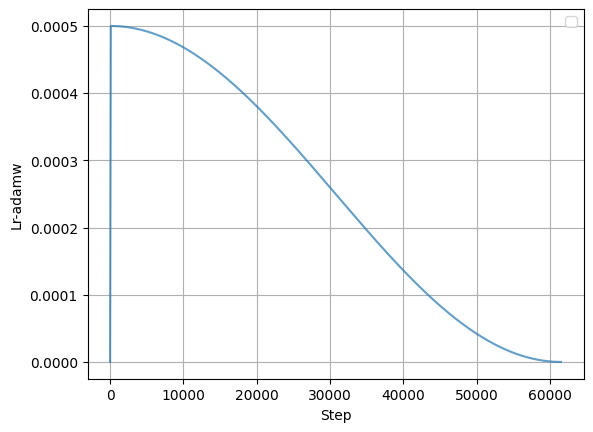

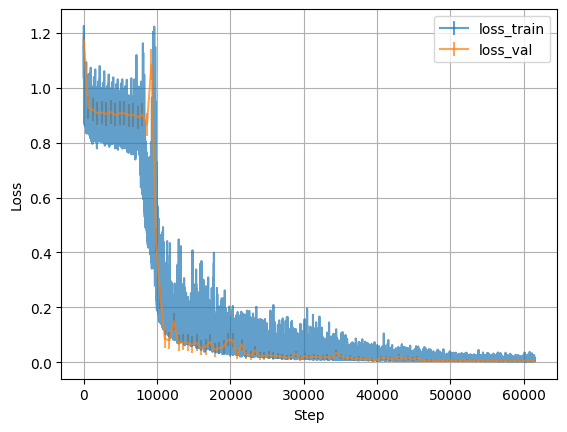

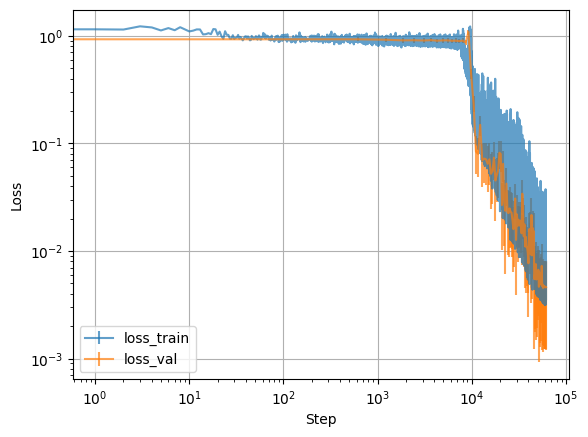

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

log_dir = mse_trans_tml_dir
plot_tensorboard(log_dir)


         step       tag     value  dir_name
0           0  lr-AdamW  0.000000          
1           1  lr-AdamW  0.000005          
2           2  lr-AdamW  0.000010          
3           3  lr-AdamW  0.000015          
4           4  lr-AdamW  0.000020          
...       ...       ...       ...       ...
130697  61500      loss  0.020743  loss_val
130698  61500      loss  0.018409  loss_val
130699  61500      loss  0.019451  loss_val
130700  61500      loss  0.018525  loss_val
130701  61500      loss  0.018288  loss_val

[130702 rows x 4 columns]
['lr-AdamW' 'loss']
        step       tag         value dir_name unique_tag
0          0  lr-AdamW  0.000000e+00           /lr-AdamW
1          1  lr-AdamW  5.000000e-06           /lr-AdamW
2          2  lr-AdamW  1.000000e-05           /lr-AdamW
3          3  lr-AdamW  1.500000e-05           /lr-AdamW
4          4  lr-AdamW  2.000000e-05           /lr-AdamW
...      ...       ...           ...      ...        ...
61495  61495  lr-AdamW  8.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  mi

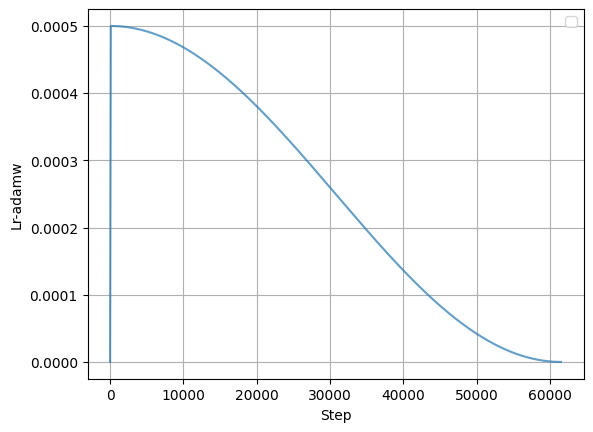

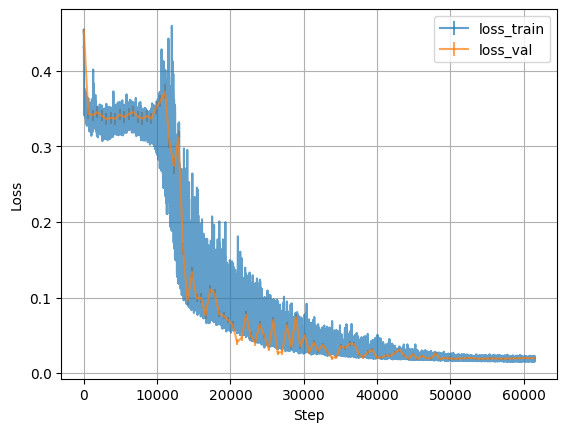

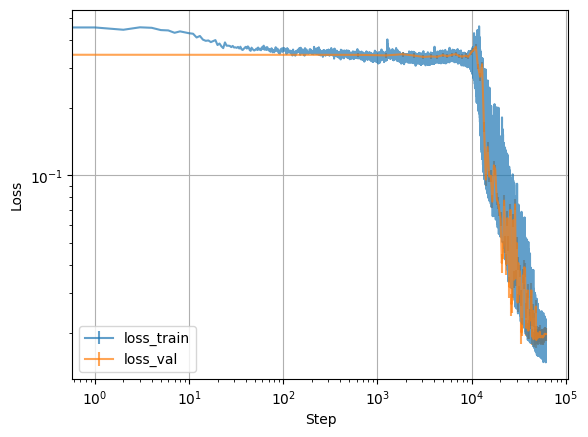

In [30]:
log_dir = qloss_tml_trasf_dir
plot_tensorboard(log_dir)

In [ ]:

batch_limit = 10
epochs = 1
attention_sum_mse = []
for epoch in tqdm(range(epochs)):
    with torch.no_grad():
        for i, (input, _, target) in enumerate(tqdm(tl)):
            if i >= batch_limit:
                break
            # Transformer MSE
            # Output shape: (n_layers, batch_size, n_heads, seq_len, seq_len)
            pred1 = transf_mse_model.get_attention_maps(input)
            # print(pred1.shape)
            # print(pred1)
            print(pred1[0].shape)
            # pt_mae1 = F.l1_loss(pred1[:, 0], target[:, 0])
            # pz_mae1 = F.l1_loss(pred1[:, 1], target[:, 1])

            # m_transf_mae_pt.append(pt_mae1.item())
            # m_transf_mae_pz.append(pz_mae1.item())

            # Add the attention maps to the attention_sum
            if len(attention_sum_mse) == 0:
                # Initialize the attention_sum to zeros with shape torch.Size([32, 4, 18, 18])
                # attention_sum_mse = [torch.zeros']
                                     
                attention_sum_mse = [torch.zeros_like(att) for att in pred1]
            for j, att in enumerate(pred1):
                attention_sum_mse[j] += att

            # Transformer Qloss
            pred2 = qloss_transf_tt_model.get_attention_maps(input)
            # print(pred2.shape)
            # print(pred2)
            # pt_mae2 = F.l1_loss(pred2[:, 0], target[:, 0])
            # pz_mae2 = F.l1_loss(pred2[:, 1], target[:, 1])

            # q_transf_mae_pt.append(pt_mae2.item())
            # q_transf_mae_pz.append(pz_mae2.item())

            # conformal fitt squares
            # pt_conf_mae = conformal_mae(input, target)
            # pt_conf_mae_list.append(pt_conf_mae.item())


In [ ]:
# Plot the attention maps
plt.figure(figsize=(12, 6))
plt.suptitle("Attention Maps", fontsize=16)

pred1 = attention_sum_mse

# MSE Model
for layer in range(len(pred1)):
    for i in range(pred1[0].shape[1]):
        plt.subplot(len(pred1), pred1[0].shape[1], layer * pred1[0].shape[1] + i + 1)
        # Plot the head with matplotlib
        # Do a mean over the batch size
        mean_attention = pred1[layer].mean(dim=0)[i].numpy()
        print(pred1[layer].mean(dim=0).shape)
        plt.imshow(mean_attention, cmap="viridis", origin="lower")
        # Add the colorbar
        plt.colorbar()
        plt.title(f"Layer {layer}, Head {i}")
plt.title("MSE Model")

# # Qloss
# plt.subplot(1, 2, 2)
# # Plot the first
# plt.imshow(pred2[0][0, 0].numpy(), cmap="viridis", origin="lower")
# plt.title("Quantile Loss Model")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [31]:
all_inputs = []
all_targets = []
all_input_masks = []
batch_limit = 10
for i, (input, masks, target) in enumerate(tqdm(tl)):
    # Reshape the input and target to shape (n_features, batch_size, seq_len)
    input = input.permute(2, 0, 1)
    target = target.permute(1, 0)

    all_inputs.append(input)
    all_targets.append(target)
    all_input_masks.append(masks)
    if i >= batch_limit:
        break

0it [00:00, ?it/s]

In [ ]:
print(all_inputs[0][0])

In [32]:
# Concatenate all the inputs and targets
all_inputs = torch.cat(all_inputs, dim=2)
all_targets = torch.cat(all_targets, dim=1)
all_input_masks = torch.cat(all_input_masks, dim=1)


# Reshape the inputs to shape (n_features, batch_size * seq_len)
all_inputs = all_inputs.view(all_inputs.shape[0], -1)

# Reshape the masks to shape (batch_size * seq_len)
all_input_masks = all_input_masks.view(-1)

print(all_inputs.shape)
print(all_targets.shape)
print(all_input_masks.shape)

torch.Size([3, 5408])
torch.Size([2, 352])
torch.Size([5408])


In [ ]:
# Print input and mask side by side
for i in range(all_inputs.shape[1]):
    print(all_inputs[:, i], all_input_masks[i])
    if i == 100:
        break

In [ ]:
# Keep input only where mask is True
all_inputs = all_inputs[:, all_input_masks]
print(all_inputs.shape)

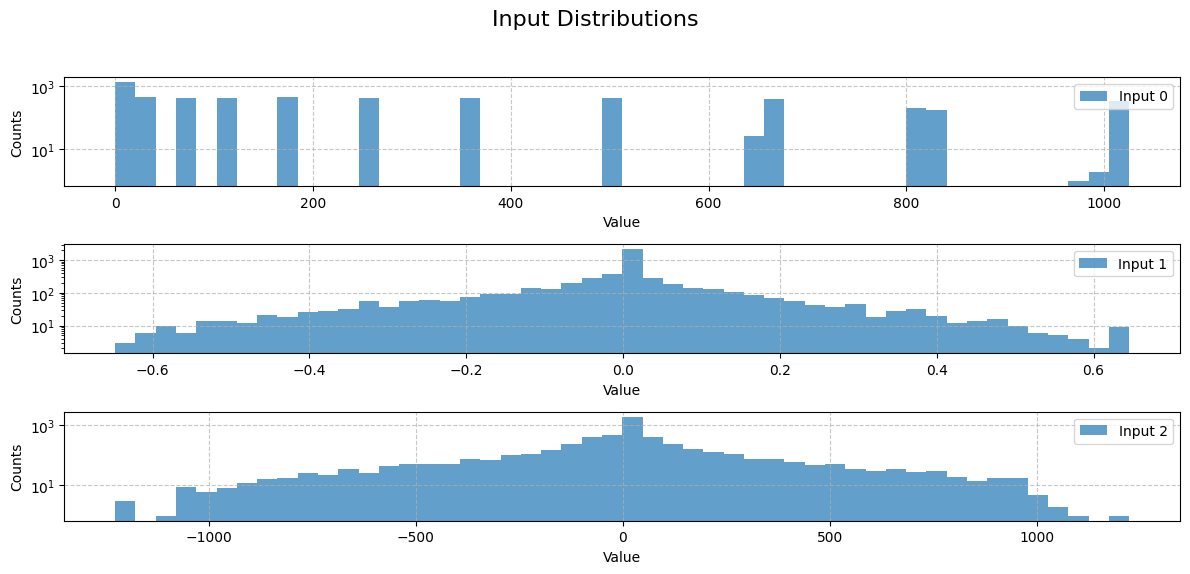

In [33]:
# Plot the distribution of the inputs
plt.figure(figsize=(12, 6))
plt.suptitle("Input Distributions", fontsize=16)

# Plot the inputs
for i in range(all_inputs.shape[0]):
    plt.subplot(all_inputs.shape[0], 1, i + 1)
    plt.hist(all_inputs[i].numpy().flatten(), bins=50, alpha=0.7, label=f"Input {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "input_distributions.png", format="png")
plt.show()


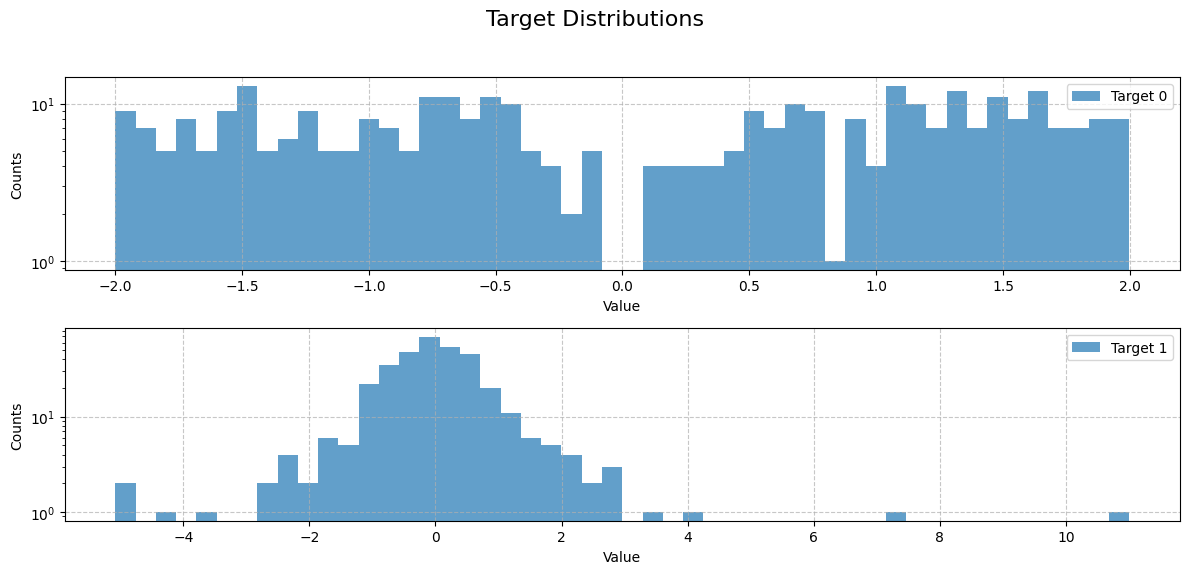

In [34]:
# Plot the distribution of the targets
plt.figure(figsize=(12, 6))
plt.suptitle("Target Distributions", fontsize=16)

# Plot the targets
for i in range(all_targets.shape[0]):
    plt.subplot(all_targets.shape[0], 1, i + 1)
    plt.hist(all_targets[i].numpy().flatten(), bins=50, alpha=0.7, label=f"Target {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "target_distributions.png", format="png")
plt.show()